This notebook is an end-to-end use case showing how Pixeltable treats video, audio, images, and text as first-class data types — storage, orchestration, and retrieval in one table interface.

> **Want to build a full app on top of this?** See the [Pixeltable Starter Kit](https://github.com/pixeltable/pixeltable-starter-kit) (FastAPI + React).

**What it does:** Turn a source video into targeted ad variants for different audiences — automatically.

## Problem

You have source videos and need short ad variants for different audiences. Manually editing each variant is slow and expensive.

| Use case | Input | Output |
|----------|-------|--------|
| Real estate | Walkthrough + buyer persona | Targeted listing ads |
| Automotive | Car review + region | Regional dealer ads |
| Hospitality | Hotel tour + season | Seasonal promo clips |
| E-commerce | Product demo + demographic | Audience-specific ads |

## Solution

**What Pixeltable handles:**

- **Storage + orchestration + retrieval in one table.** Videos, images, AI responses, and metadata live side-by-side.
- **Incremental processing.** New rows flow through the pipeline automatically. New columns backfill.
- **Caching and retries.** API calls are rate-limited, cached, and retried on failure.
- **Versioned by default.** Roll back or time-travel to any prior state.
- **Experiment, don’t plumb.** Test any transformation with `.select().head()` before committing it as a column.

```
                   ┌──────────────────────────────────────────────────────────────────┐
                   │      UNDERSTAND                 GENERATE             DELIVER     │
                   │                                                                  │
               ┌──▶ Audio ─▶ Whisper ────────────┐                                    │
              │    │       (local, free)         │                                    │
 Video ───────┤    │                             ▼                                    │
              │    │                          Ad Script ──▶ Hero Image                │
 Property ────├──▶ Scene Detect ─▶ Key Clip     (Gemini)       (Imagen)               │
   Type       │    │   (local)      │                │           │                    │
              │    │                ▼                │    first  │                    │
 Target  ─────┘    │         Gemini Multimodal ──┘   │    frame  ▼                    │
 Audience          │           (API, clip only)      │    Ad Video + Voiceover        │
                   │                                 └──▶ (Veo 3)                     │
                   │                                          │                       │
                   │                                          ▼                       │
                   │                                    Captioned Ad                  │
                   │                                    (text overlay)                │
                   │                                          │                       │
                   │                                          ▼                       │
                   │                                    Final Video ──▶ URL           │
                   │                                    (Tigris S3)                   │
                   └──────────────────────────────────────────────────────────────────┘
```

| Step | Model | Purpose |
|------|-------|---------|
| Transcribe | Whisper (local) | Verbatim transcript from full audio |
| Scene Detect | Built-in (local) | Find the most content-rich scene |
| Clip | Built-in (local) | Extract key scene as a short clip |
| Analyze | Gemini 2.5 Flash | Visual analysis of the key clip (cheaper + focused) |
| Script | Gemini 2.5 Flash | Audience-targeted ad hook |
| Image | Imagen 4.0 | Hero visual |
| Video | Veo 3 | Animated clip + voiceover from hero image |
| Captions | Built-in | Text overlay |
| Store | Tigris S3 (optional) | Presigned URLs |

**API keys needed:** Gemini only. Scene detection, clipping, and Whisper all run locally. Tigris is optional.

### Setup

In [54]:
%pip install -qU pixeltable google-genai openai-whisper scenedetect


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [55]:
import os
import getpass

if 'GEMINI_API_KEY' not in os.environ:
    os.environ['GEMINI_API_KEY'] = getpass.getpass('Gemini API Key: ')

# Optional: Tigris storage for sharing generated videos via URLs
if 'AWS_ACCESS_KEY_ID' not in os.environ:
    os.environ['AWS_ACCESS_KEY_ID'] = getpass.getpass('Tigris Access Key ID (or press Enter to skip): ')
    if os.environ['AWS_ACCESS_KEY_ID']:
        os.environ['AWS_SECRET_ACCESS_KEY'] = getpass.getpass('Tigris Secret Access Key: ')
        bucket_name = getpass.getpass('Tigris Bucket Name: ')
        os.environ['AWS_ENDPOINT_URL_S3'] = 'https://t3.storage.dev'
        os.environ['AWS_REGION'] = 'auto'
    else:
        bucket_name = None
else:
    bucket_name = os.environ.get('TIGRIS_BUCKET', 'pxt-test')

In [56]:
import re

import pixeltable as pxt
from google.genai.types import GenerateImagesConfigDict
from pixeltable.functions import gemini, whisper
from pixeltable.functions.video import concat_videos

In [57]:
pxt.drop_dir('video_ads', force=True)
pxt.create_dir('video_ads')

Created directory 'video_ads'.


## Build the Ad Pipeline

### Step 1: Source Videos Table

In [58]:
ads = pxt.create_table(
    'video_ads.ads',
    {
        'video': pxt.Video,
        'property_type': pxt.String,
        'target_audience': pxt.String,
    }
)

Created table 'ads'.


### Step 2: Understand the Video

Two parallel paths extract meaning from the source video:

- **Path A — Whisper** (local): transcribes the full audio for an exact verbatim transcript.
- **Path B — Scene Detection → Clip → Gemini**: instead of sending the entire video to the API, we detect scenes, pick the most content-rich one, and send only that clip to Gemini for visual analysis. Cheaper and more focused.

In [59]:
@pxt.udf
def pick_best_scene(scenes: pxt.Json) -> pxt.Json:
    """Pick the longest scene — likely the most content-rich."""
    if not scenes:
        return {'start_time': 0.0, 'duration': 10.0}
    return max(scenes, key=lambda s: s['duration'])


@pxt.udf
def video_analysis_prompt(
    key_clip: pxt.Video | None, video: pxt.Video, property_type: str
) -> pxt.Json:
    """Pair a video clip with an analysis prompt for Gemini multimodal.
    Falls back to the full video if key_clip is None (scene detection failed)."""
    v = key_clip if key_clip is not None else video
    return [
        v,
        f'Analyze this {property_type} video. Describe the key visuals, mood, '
        'production quality, and selling points. Be specific and concise.'
    ]

In [60]:
# Path A: Local Whisper transcription on full audio (exact verbatim text)
ads.add_computed_column(audio=ads.video.extract_audio(format='wav'))
ads.add_computed_column(transcription=whisper.transcribe(ads.audio, model='base'))
ads.add_computed_column(transcript=ads.transcription['text'].astype(pxt.String))

# Path B: Scene detection → extract key clip → Gemini analysis on the clip
ads.add_computed_column(scenes=ads.video.scene_detect_content())
ads.add_computed_column(best_scene=pick_best_scene(ads.scenes))
ads.add_computed_column(
    key_clip=ads.video.clip(
        start_time=ads.best_scene['start_time'].astype(pxt.Float),
        duration=ads.best_scene['duration'].astype(pxt.Float)
    )
)
ads.add_computed_column(
    analysis_contents=video_analysis_prompt(ads.key_clip, ads.video, ads.property_type)
)
ads.add_computed_column(
    video_analysis=gemini.generate_content(
        ads.analysis_contents,
        model='gemini-2.5-flash'
    )
)
ads.add_computed_column(
    analysis_text=ads.video_analysis['candidates'][0]['content']['parts'][0]['text'].astype(pxt.String)
)

Added 0 column values with 0 errors in 0.01 s
Added 0 column values with 0 errors in 0.01 s
Added 0 column values with 0 errors in 0.02 s
Added 0 column values with 0 errors in 0.01 s
Added 0 column values with 0 errors in 0.01 s
Added 0 column values with 0 errors in 0.01 s
Added 0 column values with 0 errors in 0.01 s
Added 0 column values with 0 errors in 0.01 s
Added 0 column values with 0 errors in 0.01 s


No rows affected.

### Step 3: Generate Ad Script

Gemini writes the ad script using both the Whisper transcript and the Gemini visual analysis.

In [61]:
@pxt.udf
def ad_script_prompt(
    transcript: str | None, analysis: str | None, property_type: str, target_audience: str
) -> str:
    """Combine transcript + visual analysis into a script prompt."""
    parts = []
    if transcript:
        parts.append(f'TRANSCRIPT: {transcript[:600]}')
    if analysis:
        parts.append(f'VISUAL ANALYSIS: {analysis[:600]}')
    context = '\n\n'.join(parts) if parts else f'A {property_type} property video.'
    return (
        f'Write a 2-3 sentence video ad hook (under 15 seconds spoken) for a '
        f'{property_type} listing targeting {target_audience}.\n\n'
        f'{context}\n\n'
        'Use available details. Conversational and specific. '
        'Return ONLY the script text.'
    )

In [62]:
ads.add_computed_column(
    script_prompt=ad_script_prompt(
        ads.transcript, ads.analysis_text, ads.property_type, ads.target_audience
    )
)

ads.add_computed_column(
    script_response=gemini.generate_content(
        ads.script_prompt,
        model='gemini-2.5-flash'
    )
)

ads.add_computed_column(
    ad_script=ads.script_response['candidates'][0]['content']['parts'][0]['text'].astype(pxt.String)
)

Added 0 column values with 0 errors in 0.02 s
Added 0 column values with 0 errors in 0.02 s
Added 0 column values with 0 errors in 0.01 s


No rows affected.

### Step 4: Generate Hero Image with Imagen

In [63]:
@pxt.udf
def image_prompt(ad_script: str | None, property_type: str) -> str:
    """Build prompt for Imagen hero image."""
    mood = f'evoking: "{ad_script[:200]}"' if ad_script else 'warm and inviting mood'
    return (
        f'Cinematic vertical photo of a {property_type}, golden-hour lighting, '
        f'{mood}. No text or watermarks.'
    )

In [64]:
ads.add_computed_column(
    image_prompt=image_prompt(ads.ad_script, ads.property_type)
)

ads.add_computed_column(
    hero_image=gemini.generate_images(
        ads.image_prompt,
        model='imagen-4.0-fast-generate-001',
        config=GenerateImagesConfigDict(aspect_ratio='9:16')
    )
)

Added 0 column values with 0 errors in 0.02 s
Added 0 column values with 0 errors in 0.01 s


No rows affected.

### Step 5: Generate Ad Video with Veo 3

Veo 3 generates both video **and** voiceover in a single call. We include the ad script as narration in the prompt, so there's no need for a separate TTS step.

In [65]:
@pxt.udf
def video_prompt(ad_script: str | None) -> str:
    """Build a Veo 3 prompt: cinematic visuals + voiceover from the ad script."""
    base = 'Subtle cinematic camera movement, professional footage, warm lighting, smooth motion.'
    if not ad_script:
        return base
    return (
        f'{base} '
        f'A confident, professional narrator speaks the following voiceover clearly: "{ad_script}"'
    )

ads.add_computed_column(video_prompt=video_prompt(ads.ad_script))

ads.add_computed_column(
    ad_video=gemini.generate_videos(
        prompt=ads.video_prompt,
        image=ads.hero_image,
        model='veo-3.0-generate-001'
    )
)

Added 0 column values with 0 errors in 0.03 s
Added 0 column values with 0 errors in 0.01 s


No rows affected.

### Step 6: Add Captions

In [66]:
@pxt.udf
def clean_caption(text: str) -> str:
    """Strip markdown artifacts and truncate for on-screen display."""
    clean = re.sub(r'[*_#"\'\n]+', ' ', text).strip()
    clean = re.sub(r' {2,}', ' ', clean)
    return clean[:57].rsplit(' ', 1)[0] + '...' if len(clean) > 60 else clean


ads.add_computed_column(caption=clean_caption(ads.ad_script))

ads.add_computed_column(
    captioned_ad=ads.ad_video.overlay_text(
        ads.caption,
        font_size=28,
        color='white',
        box=True,
        box_color='black',
        box_opacity=0.7,
        box_border=[8, 16],
        horizontal_align='center',
        vertical_align='bottom',
        vertical_margin=80
    )
)

Added 0 column values with 0 errors in 0.01 s
Added 0 column values with 0 errors in 0.01 s


No rows affected.

### Step 7: Store for Sharing (Optional)

In [67]:
if bucket_name:
    try:
        ads.add_computed_column(
            final_video=ads.captioned_ad,
            destination=f's3://{bucket_name}/video-ads/'
        )
    except Exception as e:
        bucket_name = None
        print(f'Tigris storage skipped ({e}). Videos will be stored locally.')

Added 0 column values with 0 errors in 0.01 s


## Demo: Generate a Property Ad

In [ ]:
sample_video_url = 'https://videos.pexels.com/video-files/7347880/7347880-hd_1920_1080_25fps.mp4'

ads.insert([
    {
        'video': sample_video_url,
        'property_type': 'modern home',
        'target_audience': 'young families'
    }
])

In [ ]:
ads.select(
    ads.property_type,
    ads.target_audience,
    ads.key_clip,
    ads.transcript,
    ads.analysis_text
).head()

property_type,target_audience,transcript,analysis_text
luxury condo,luxury seekers,"of experiencing self versus remembering self. I was hoping you can give a simple answer of how we should live life. Uh, based on the fact that our memories could be a source of happiness or could be the primary source of happiness, that an event when experienced bears its fruits the most when it's remembered over and over and over and over and maybe there is some wisdom in the fact that we can control to some degree how we remember it, how we evolve our memory of it, such that it can maximize the long term happiness of that repeated experience. Okay, well first I'll say I wish I could take you on the road with me. That was such a great description. Can I be your opening answer? Oh my God, no, I've got to open for you, dude. Otherwise it's like, you know, everybody leaves after you're done. You're done.","The provided video clip is not of a luxury condo. It features two men in what appears to be a podcast or interview setting. Here's a breakdown of what is actually visible: * **Key Visuals:** Two men, one speaking at a microphone and the other listening/reacting. The man speaking is wearing a black suit and white shirt with a black tie. The man listening/reacting is wearing a dark suit jacket and a dark blue collared shirt with glasses. There's a microphone on a boom arm, a bottle of Coca ...... lling points for a property. However, in the context of a podcast, the ""selling points"" would be: * **Engaging Discussion:** The topic of ""experiencing self versus remembering self"" and how to live life suggests a philosophical and thought-provoking conversation. * **Credible Speakers:** The attire and setting give an impression of professionalism and expertise. * **High Production Value:** Indicates a serious and well-resourced podcast, which can attract viewers/listeners."


target_audience,ad_script,hero_image
luxury seekers,"We talk about how memories shape our happiness, and truly, the greatest life is one you love to remember. What if your luxury condo was that daily source of joy, a masterfully curated space? From serene mornings to stunning evenings, every detail here is designed for unforgettable experiences.",

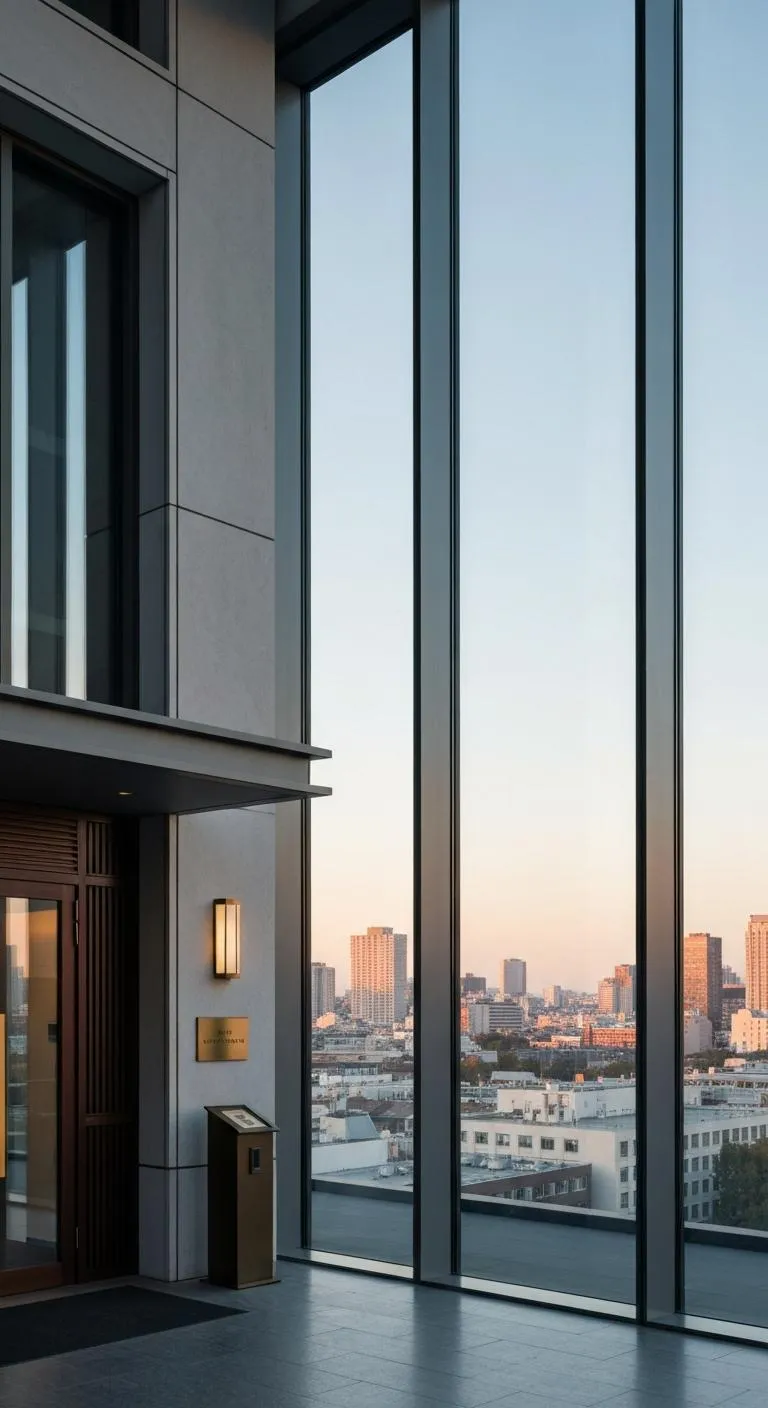

In [ ]:
ads.select(
    ads.target_audience,
    ads.ad_script,
    ads.hero_image
).head()

target_audience,captioned_ad
luxury seekers,

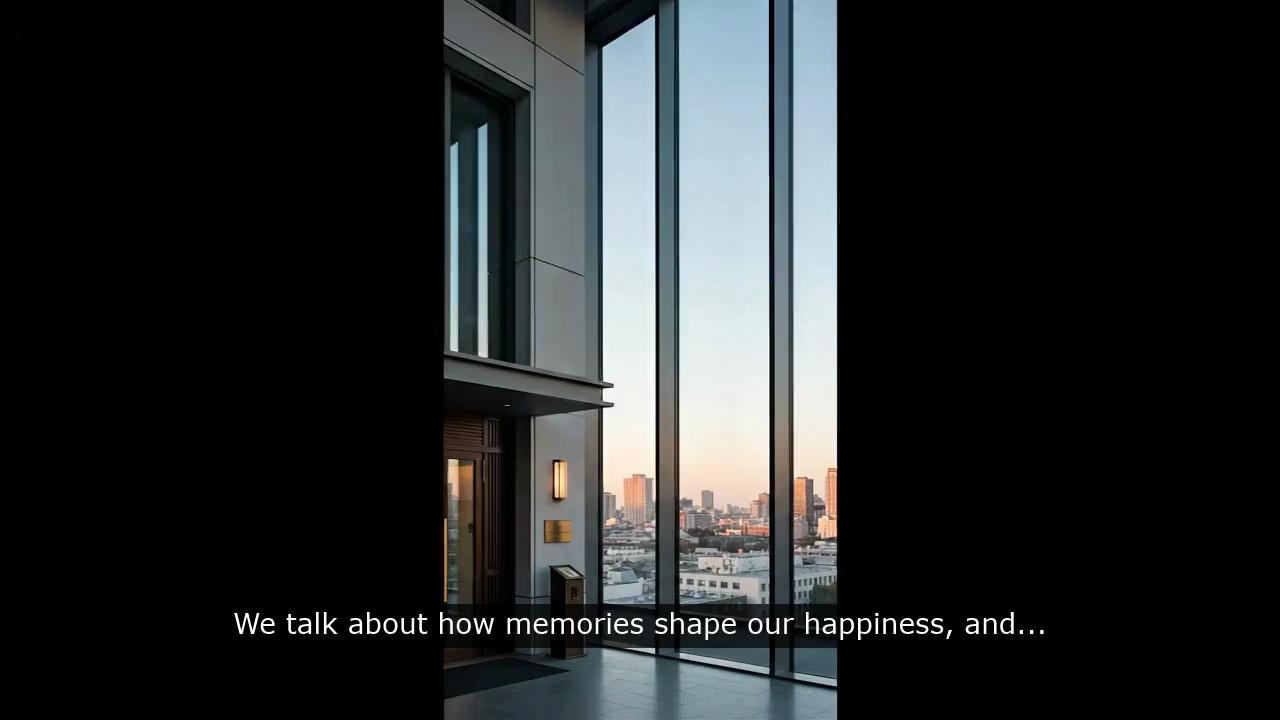

In [ ]:
ads.select(
    ads.target_audience,
    ads.captioned_ad
).head()

### Share via Presigned URLs

In [ ]:
if bucket_name:
    from pixeltable.functions import net

    ads.select(
        ads.target_audience,
        ads.ad_script,
        shareable_url=net.presigned_url(ads.final_video.fileurl, 3600)
    ).head()

## Scale: Multiple Audiences from One Video

Same video, different audiences — each gets a unique ad.

In [ ]:
ads.insert([
    {'video': sample_video_url, 'property_type': 'modern home', 'target_audience': 'first-time buyers'},
    {'video': sample_video_url, 'property_type': 'modern home', 'target_audience': 'investors'},
    {'video': sample_video_url, 'property_type': 'modern home', 'target_audience': 'relocators'},
])

/opt/miniconda3/envs/pixeltable/lib/python3.11/site-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")
/opt/miniconda3/envs/pixeltable/lib/python3.11/site-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")
/opt/miniconda3/envs/pixeltable/lib/python3.11/site-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


Inserted 3 rows with 0 errors in 149.48 s (0.02 rows/s)


3 rows inserted.

video property_type  \
0  /Users/pjlb/.pixeltable/file_cache/8554d8668db...  luxury condo   
1  /Users/pjlb/.pixeltable/file_cache/8554d8668db...  luxury condo   
2  /Users/pjlb/.pixeltable/file_cache/8554d8668db...  luxury condo   
3  /Users/pjlb/.pixeltable/file_cache/8554d8668db...  luxury condo   

     target_audience                                              audio  \
0     luxury seekers  /Users/pjlb/.pixeltable/media/0045af123e744013...   
1  first-time buyers  /Users/pjlb/.pixeltable/media/0045af123e744013...   
2          investors  /Users/pjlb/.pixeltable/media/0045af123e744013...   
3         relocators  /Users/pjlb/.pixeltable/media/0045af123e744013...   

                                       transcription  \
0  {'text': ' of experiencing self versus remembe...   
1  {'text': ' of experiencing self versus remembe...   
2  {'text': ' of experiencing self versus remembe...   
3  {'text': ' of experiencing self versus remembe...   

                                          transcript  \
0   of experiencing self versus remembering self....   
1   of experiencing self versus remembering self....   
2   of experiencing self versus remembering self....   
3   of experiencing self versus remembering self....   

                                   analysis_contents  \
0  [/Users/pjlb/.pixeltable/file_cache/8554d8668d...   
1  [/Users/pjlb/.pixeltable/file_cache/8554d8668d...   
2  [/Users/pjlb/.pixeltable/file_cache/8554d8668d...   
3  [/Users/pjlb/.pixeltable/file_cache/8554d8668d...   

                                      video_analysis  \
0  {'parsed': None, 'candidates': [{'index': 0, '...   
1  {'parsed': None, 'candidates': [{'index': 0, '...   
2  {'parsed': None, 'candidates': [{'index': 0, '...   
3  {'parsed': None, 'candidates': [{'index': 0, '...   

                                       analysis_text  \
0  The provided video clip is not of a luxury con...   
1  It appears there might be a misunderstanding r...   
2  This video appears to be an **interview or pod...   
3  The provided video is **not a luxury condo vid...   

                                       script_prompt  \
0  Write a 2-3 sentence video ad hook (under 15 s...   
1  Write a 2-3 sentence video ad hook (under 15 s...   
2  Write a 2-3 sentence video ad hook (under 15 s...   
3  Write a 2-3 sentence video ad hook (under 15 s...   

                                     script_response  \
0  {'parsed': None, 'candidates': [{'index': 0, '...   
1  {'parsed': None, 'candidates': [{'index': 0, '...   
2  {'parsed': None, 'candidates': [{'index': 0, '...   
3  {'parsed': None, 'candidates': [{'index': 0, '...   

                                           ad_script  \
0  We talk about how memories shape our happiness...   
1  You've thought about it, discussed it, imagine...   
2  Discerning investors know true value repeatedl...   
3  Done reflecting on what makes a life well-live...   

                                        image_prompt  \
0  Cinematic vertical photo of a luxury condo, go...   
1  Cinematic vertical photo of a luxury condo, go...   
2  Cinematic vertical photo of a luxury condo, go...   
3  Cinematic vertical photo of a luxury condo, go...   

                                          hero_image  \
0  <PIL.JpegImagePlugin.JpegImageFile image mode=...   
1  <PIL.JpegImagePlugin.JpegImageFile image mode=...   
2  <PIL.JpegImagePlugin.JpegImageFile image mode=...   
3  <PIL.JpegImagePlugin.JpegImageFile image mode=...   

                                            ad_video  \
0  /Users/pjlb/.pixeltable/media/0045af123e744013...   
1  /Users/pjlb/.pixeltable/media/0045af123e744013...   
2  /Users/pjlb/.pixeltable/media/0045af123e744013...   
3  /Users/pjlb/.pixeltable/media/0045af123e744013...   

                                             caption  \
0  We talk about how memories shape our happiness...   
1  You ve thought about it, discussed it, imagine...   
2  Discerning investors know true value repeatedl...   
3  Do
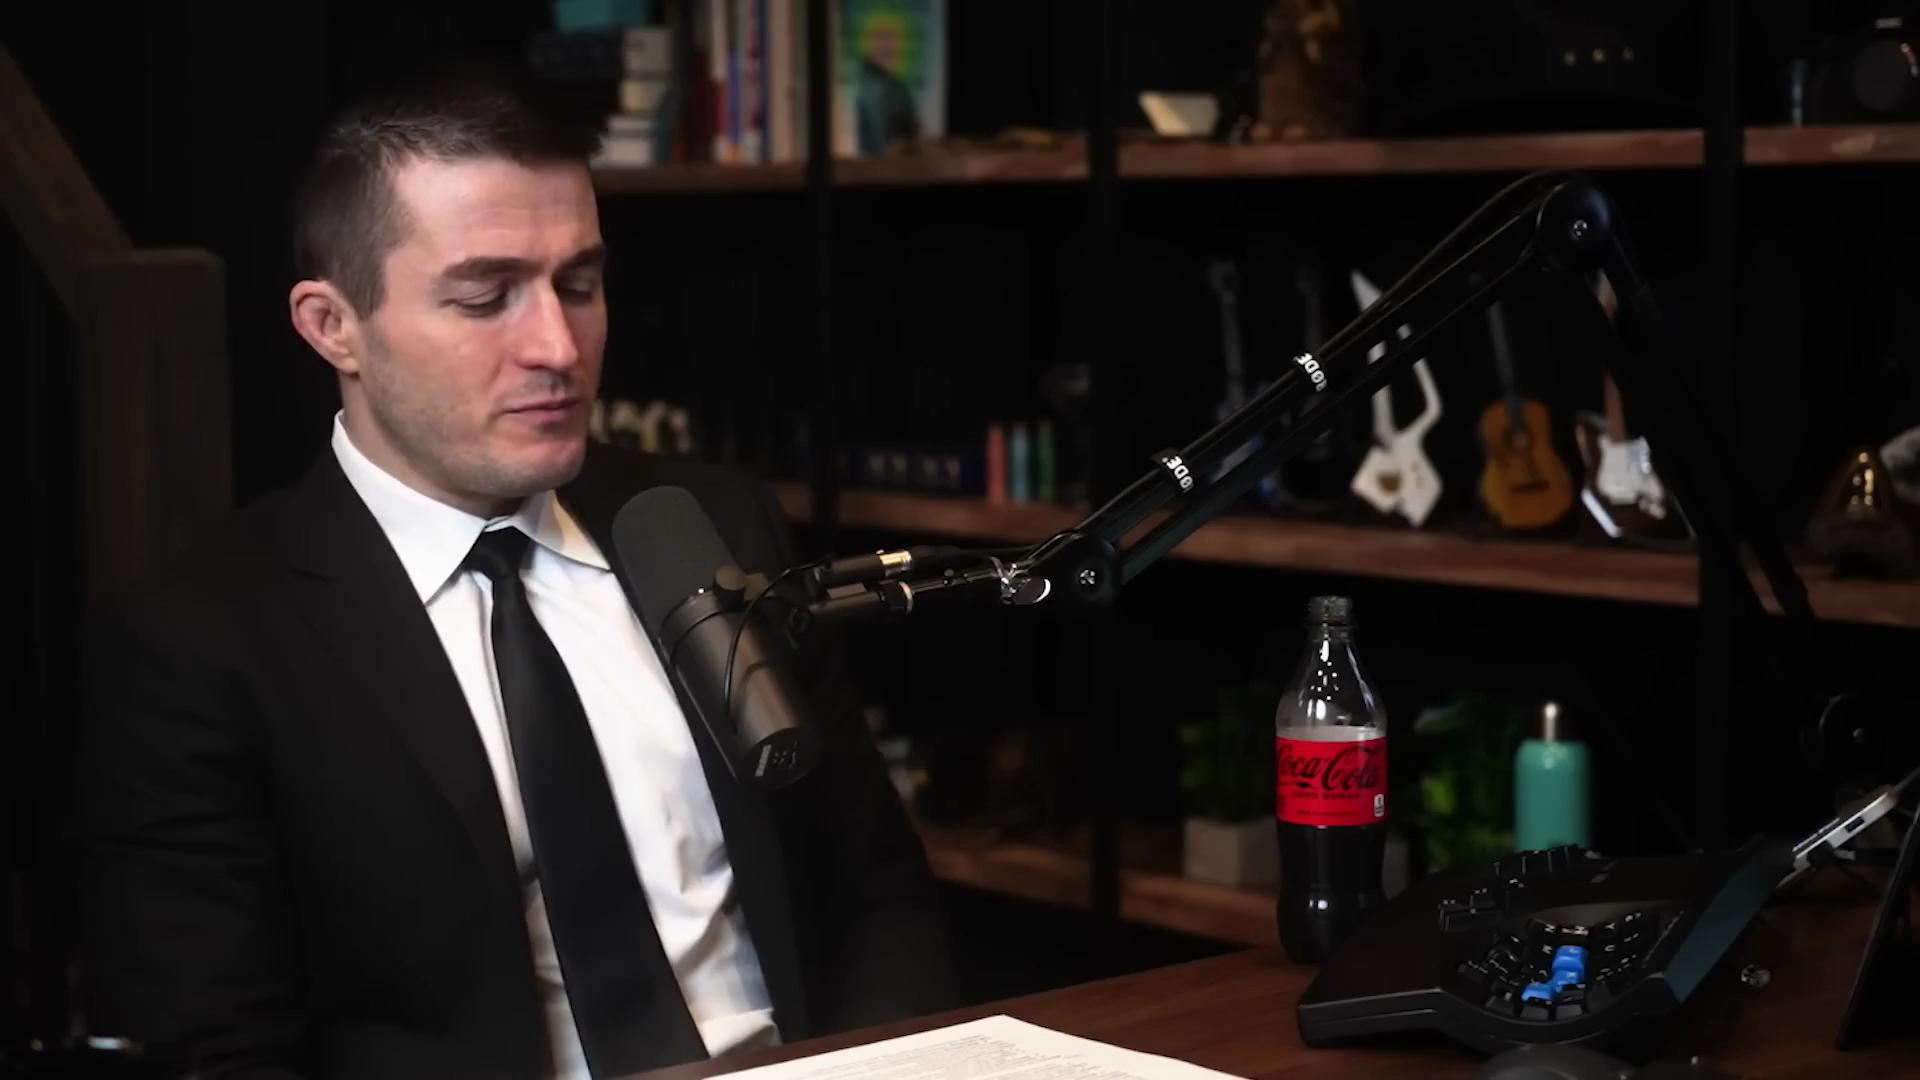
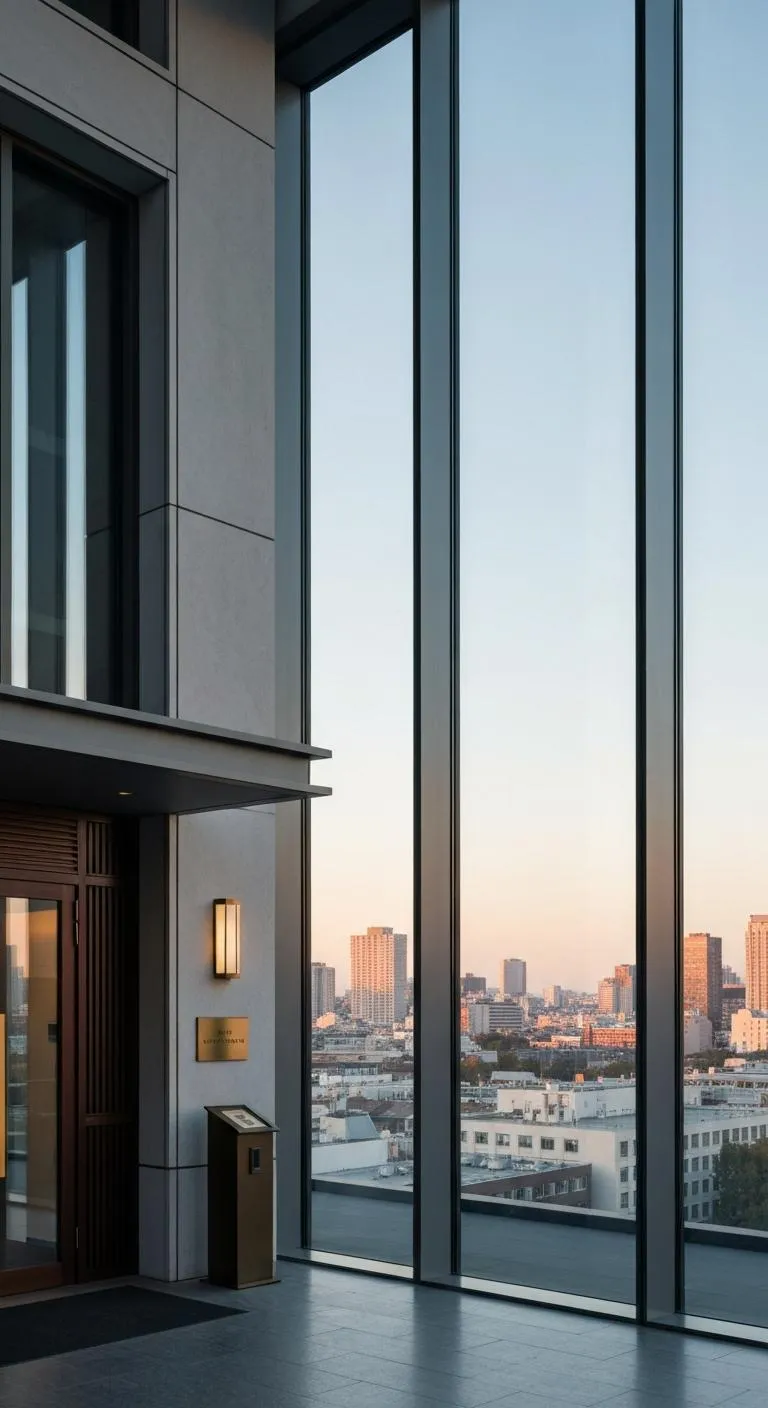
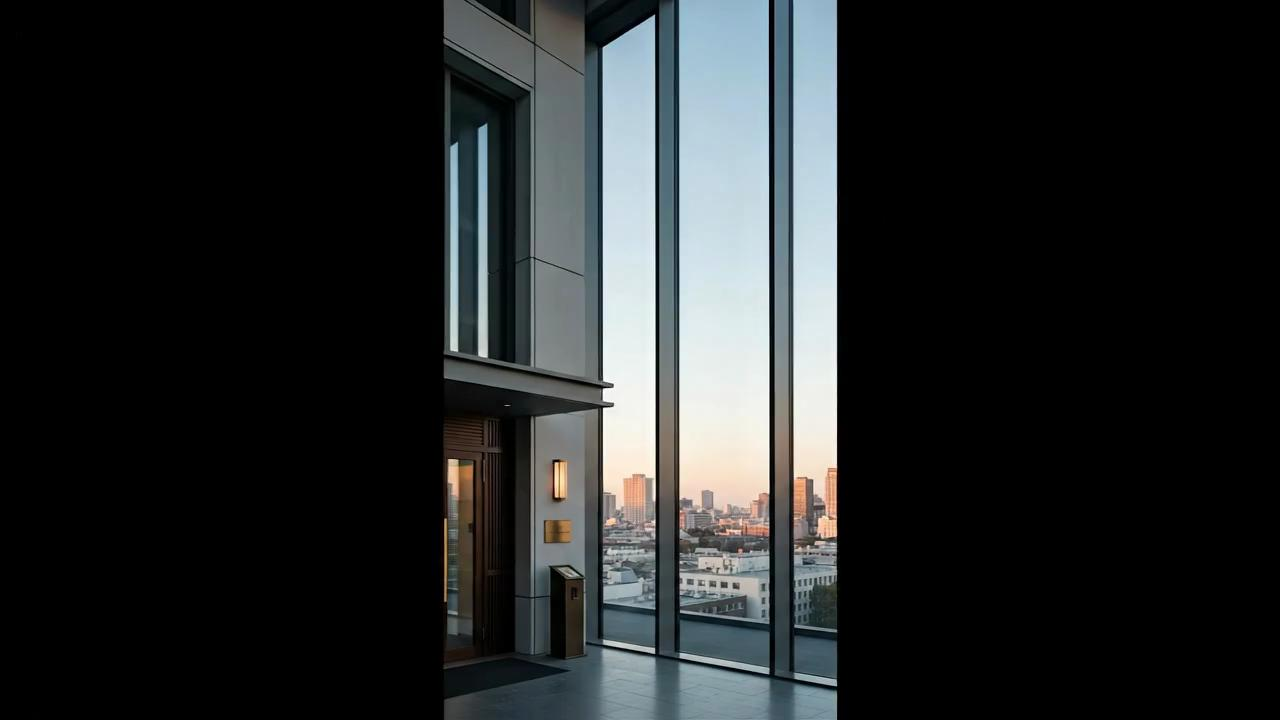
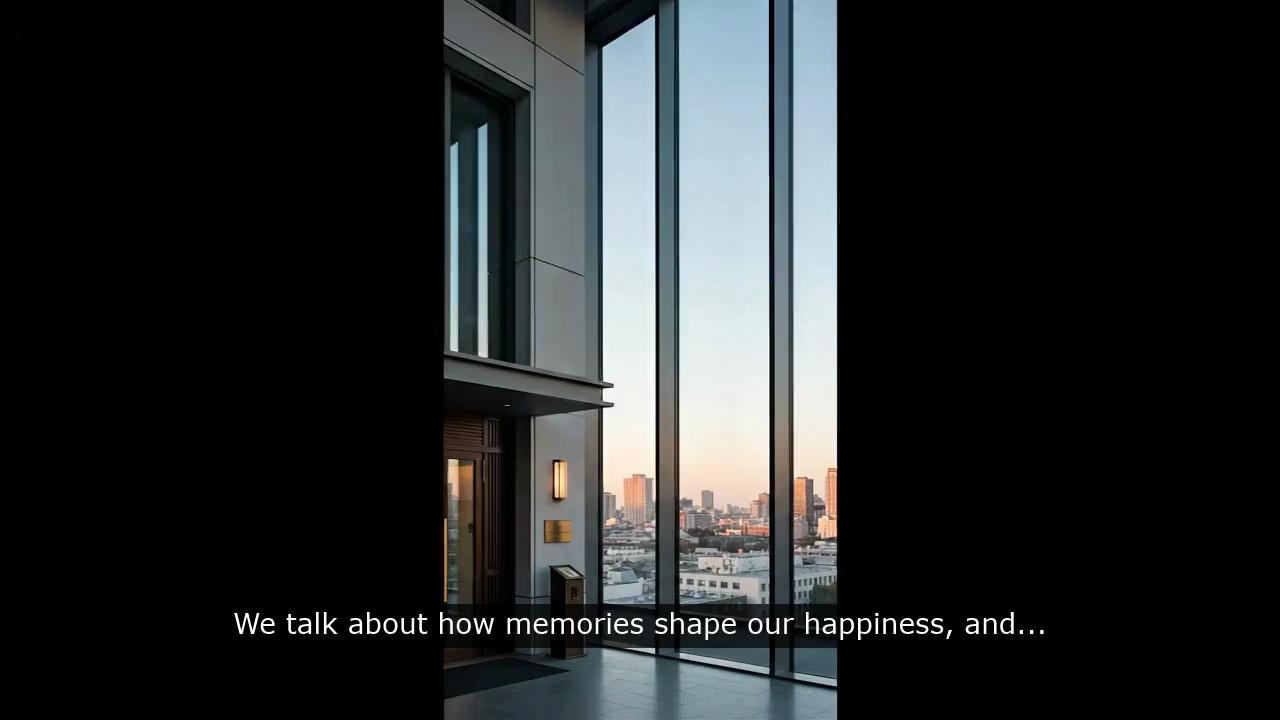
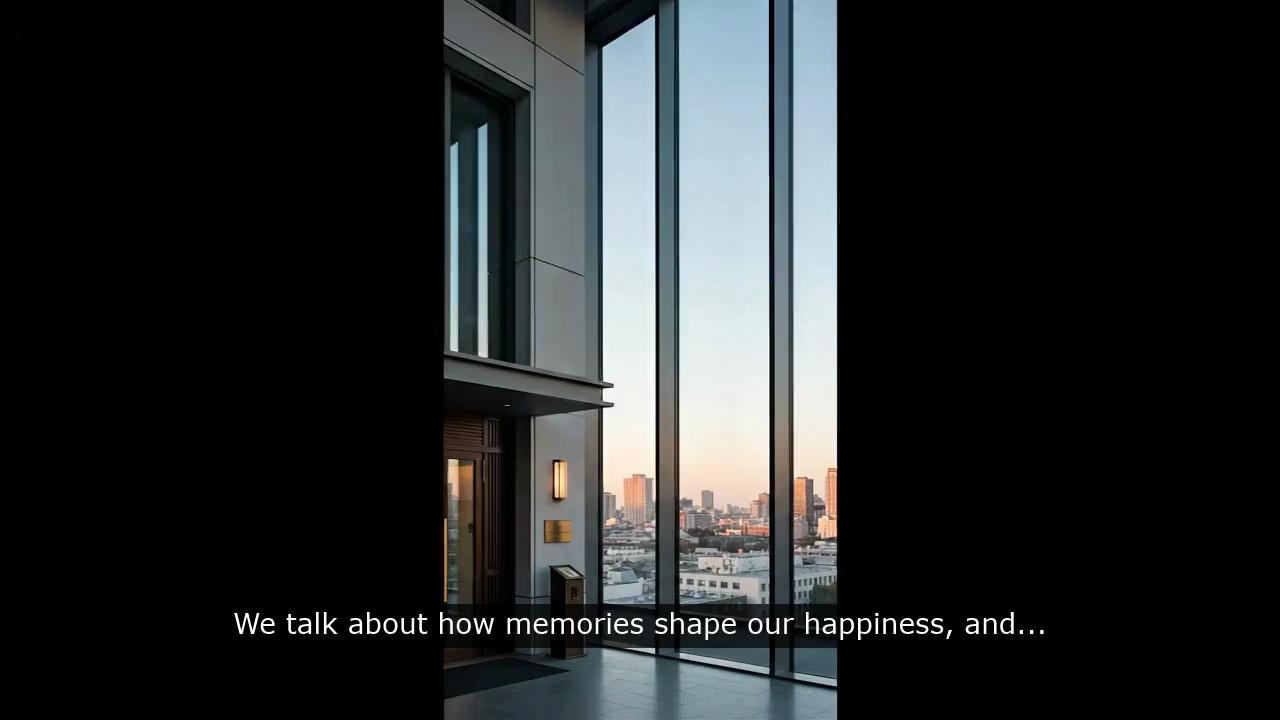
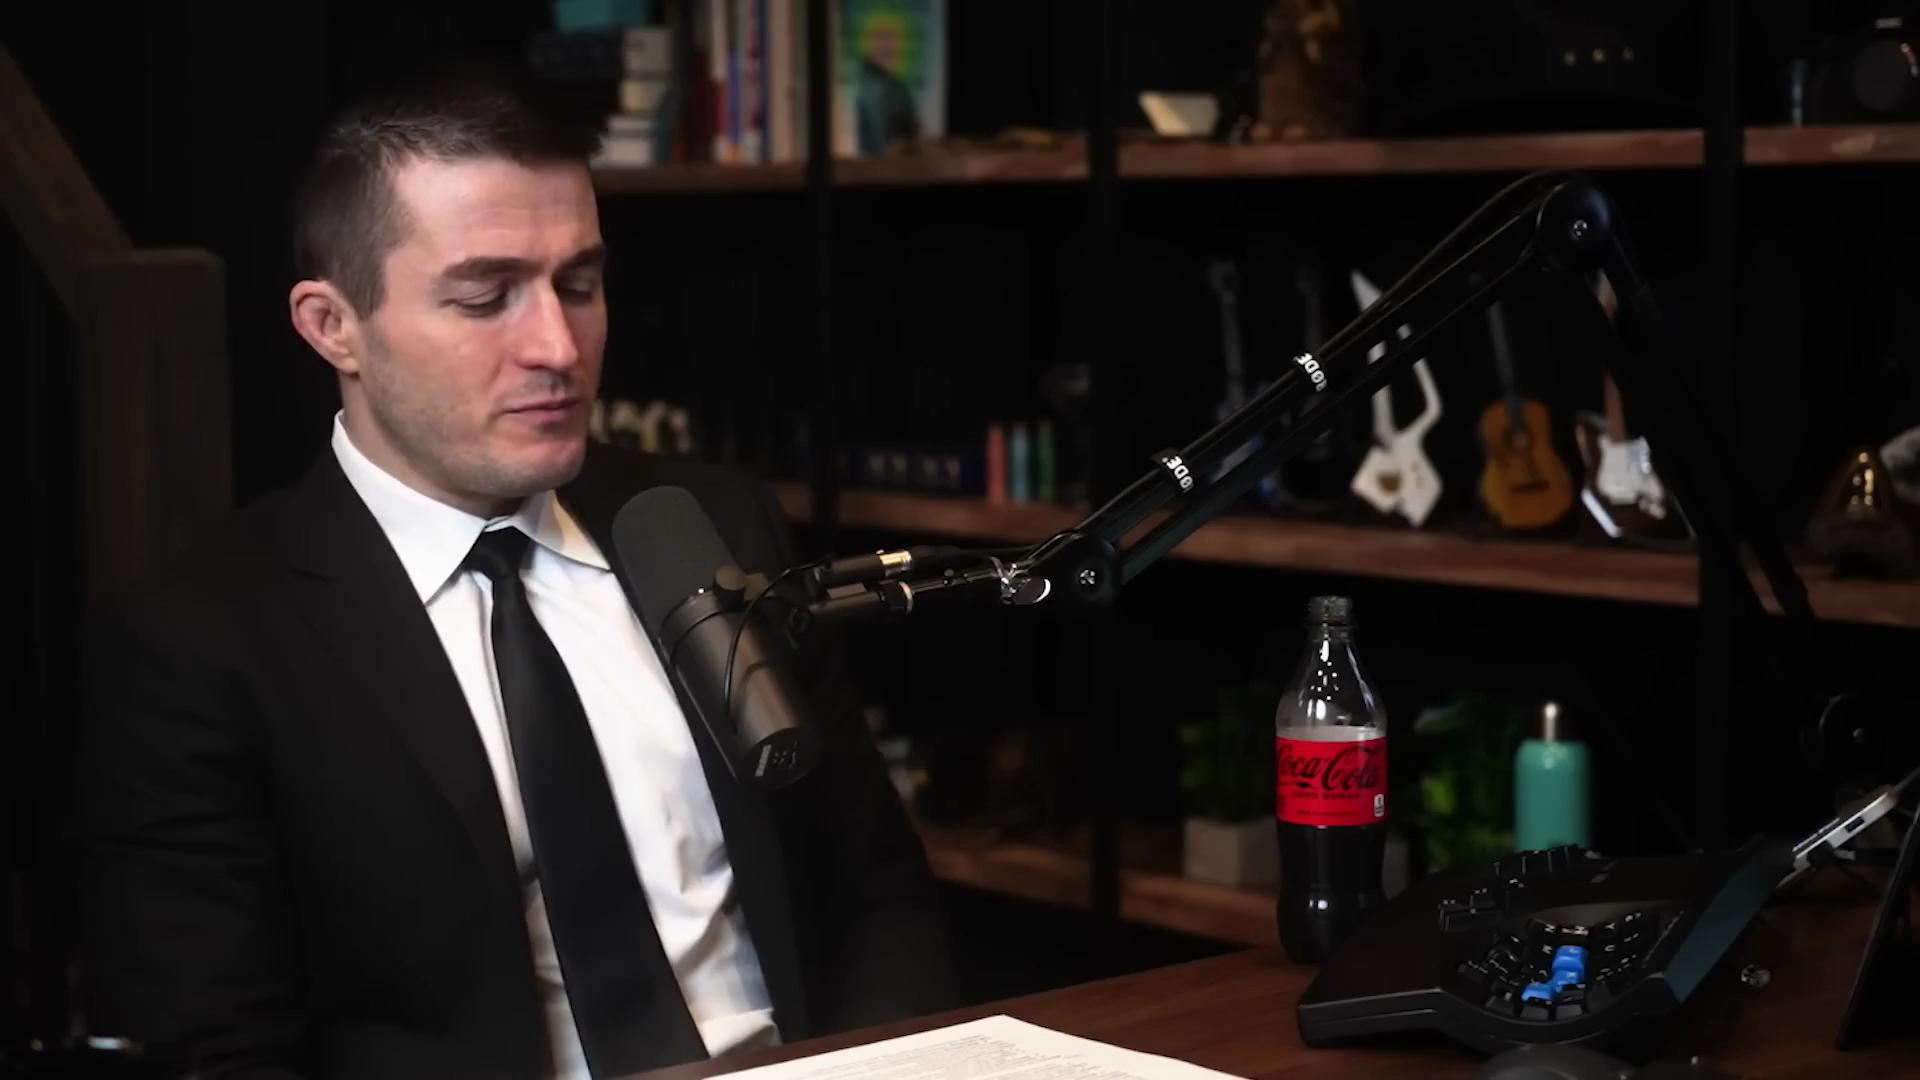
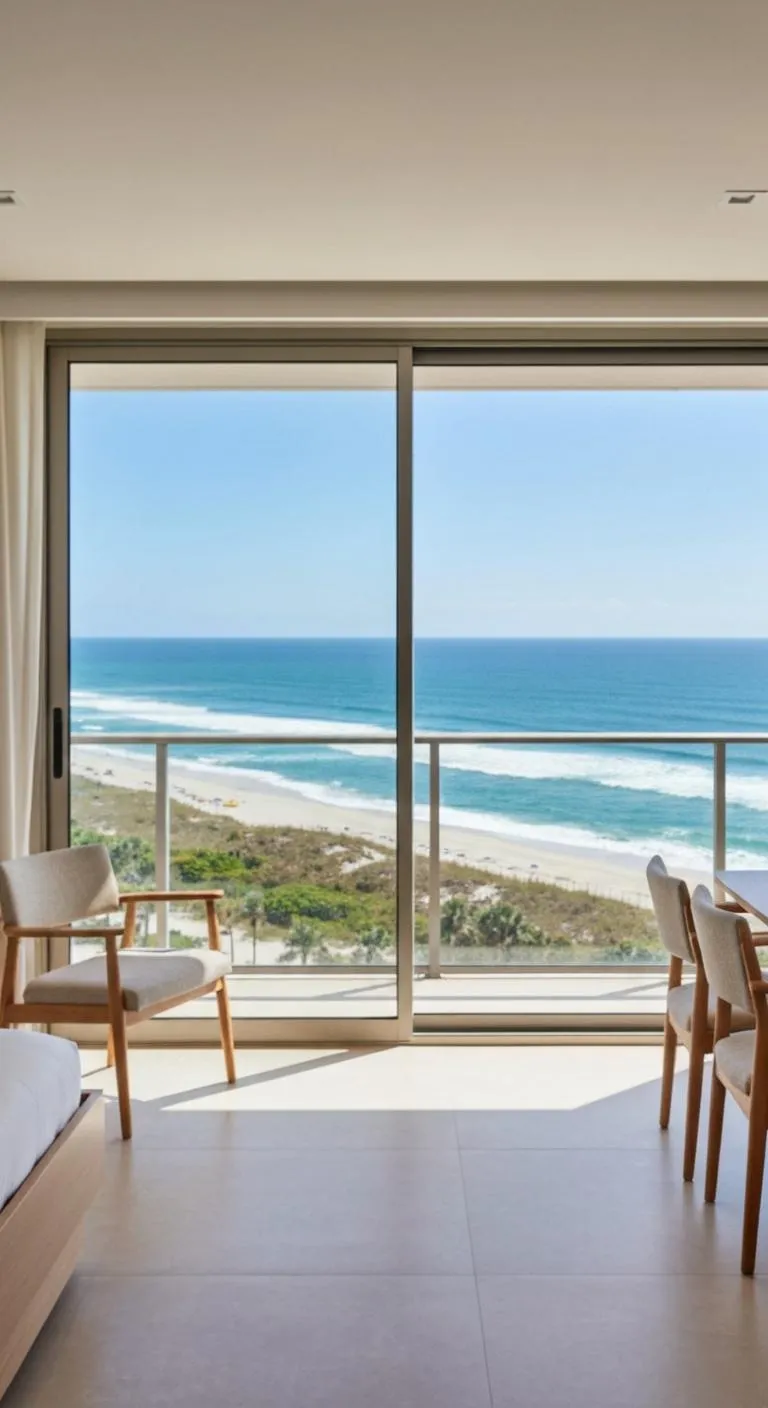
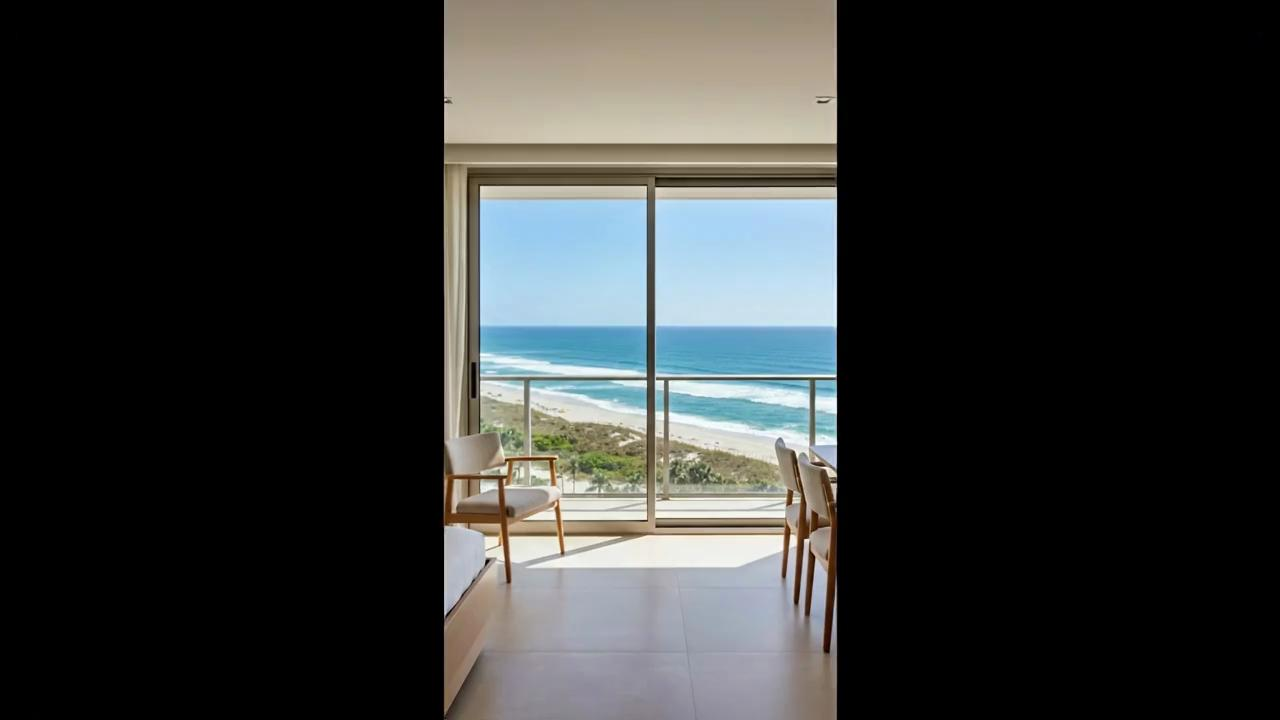
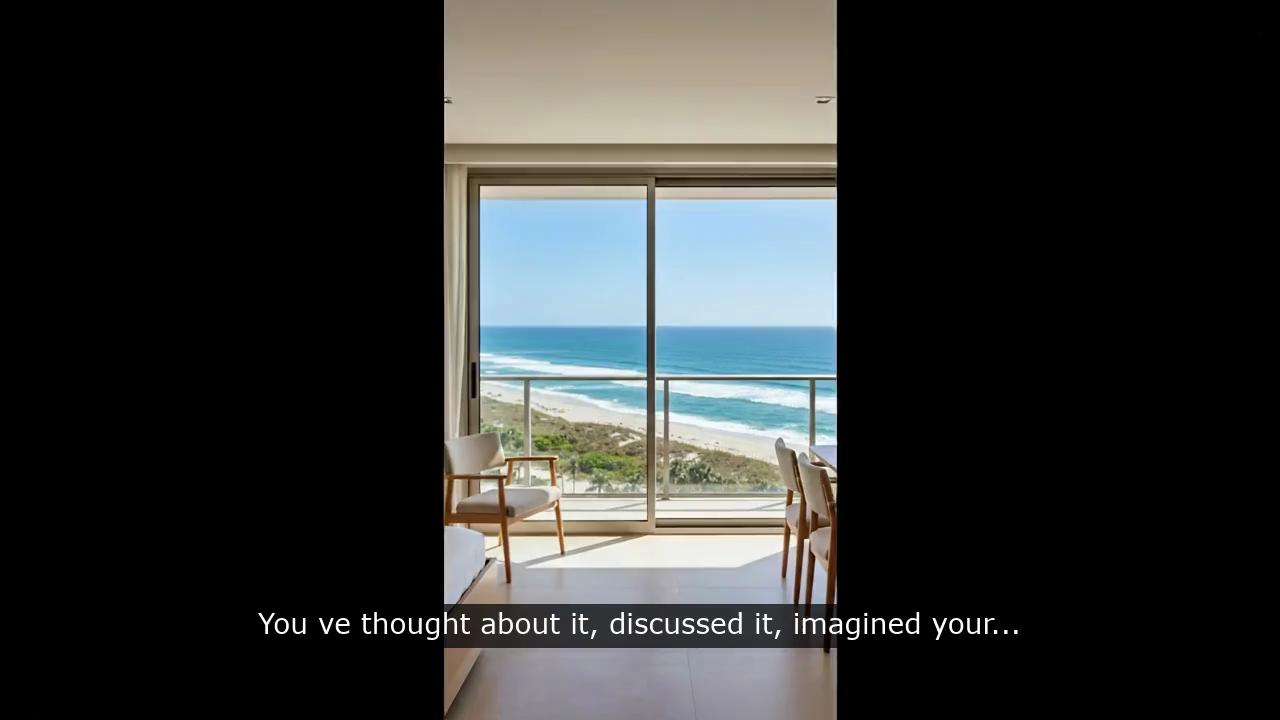
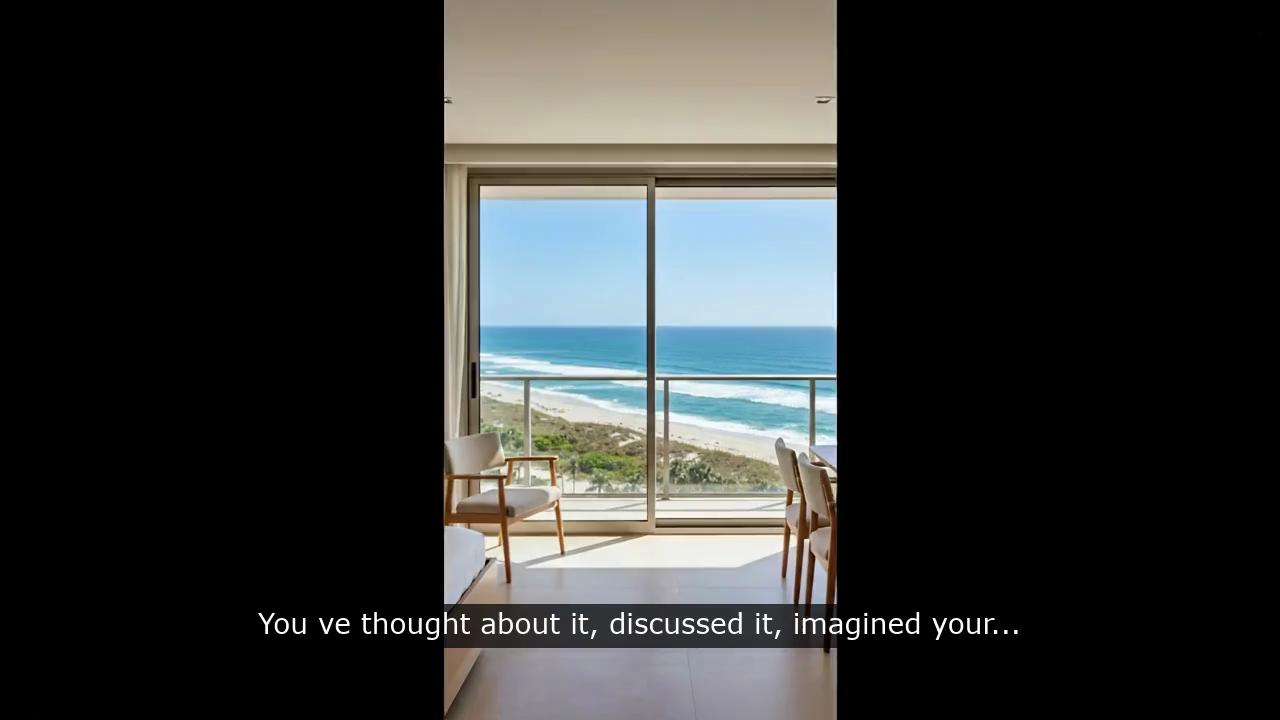
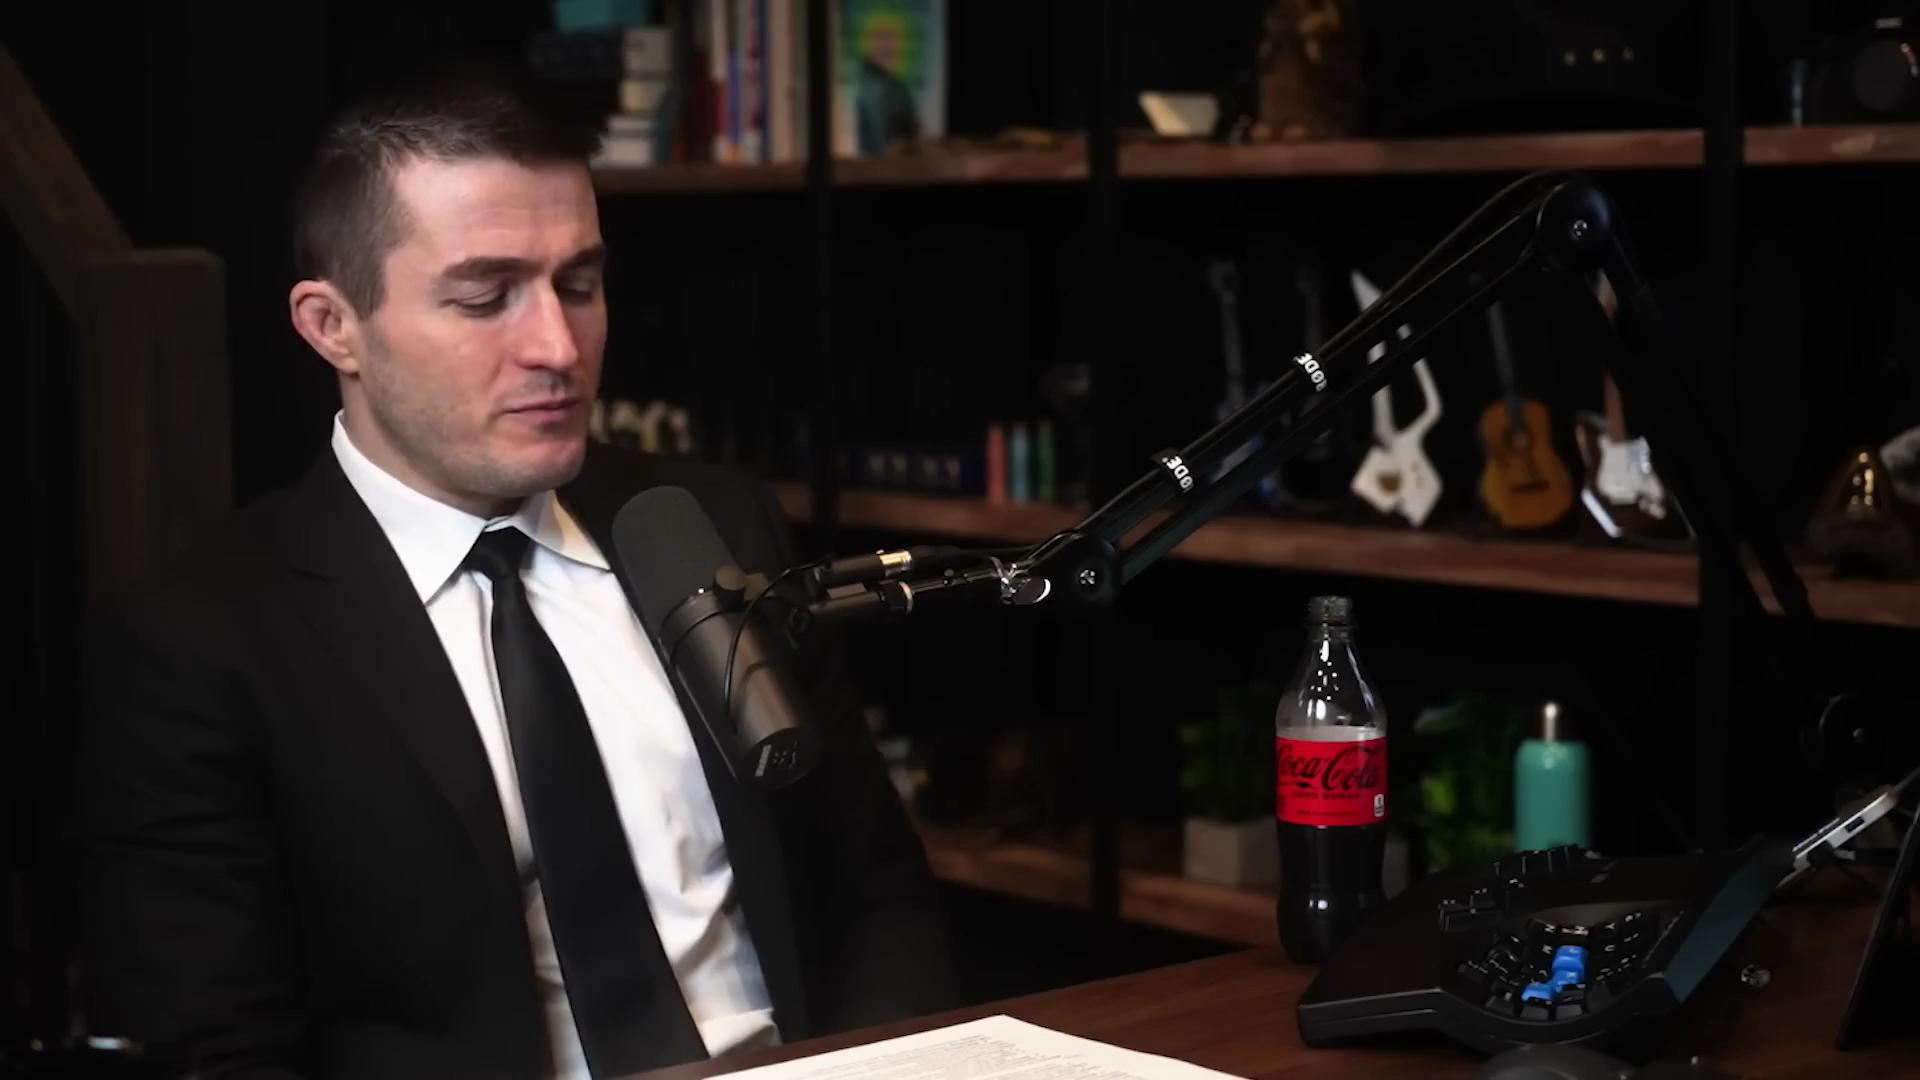
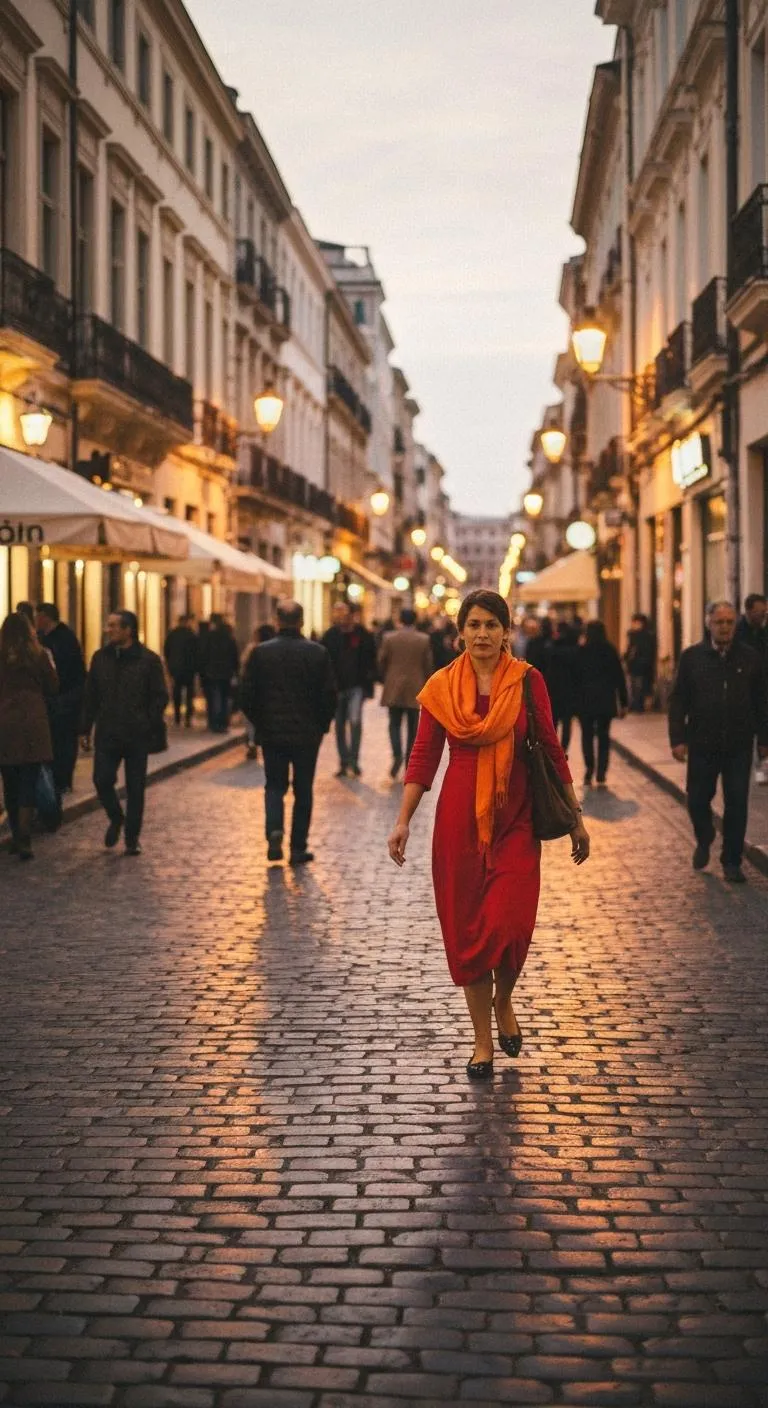
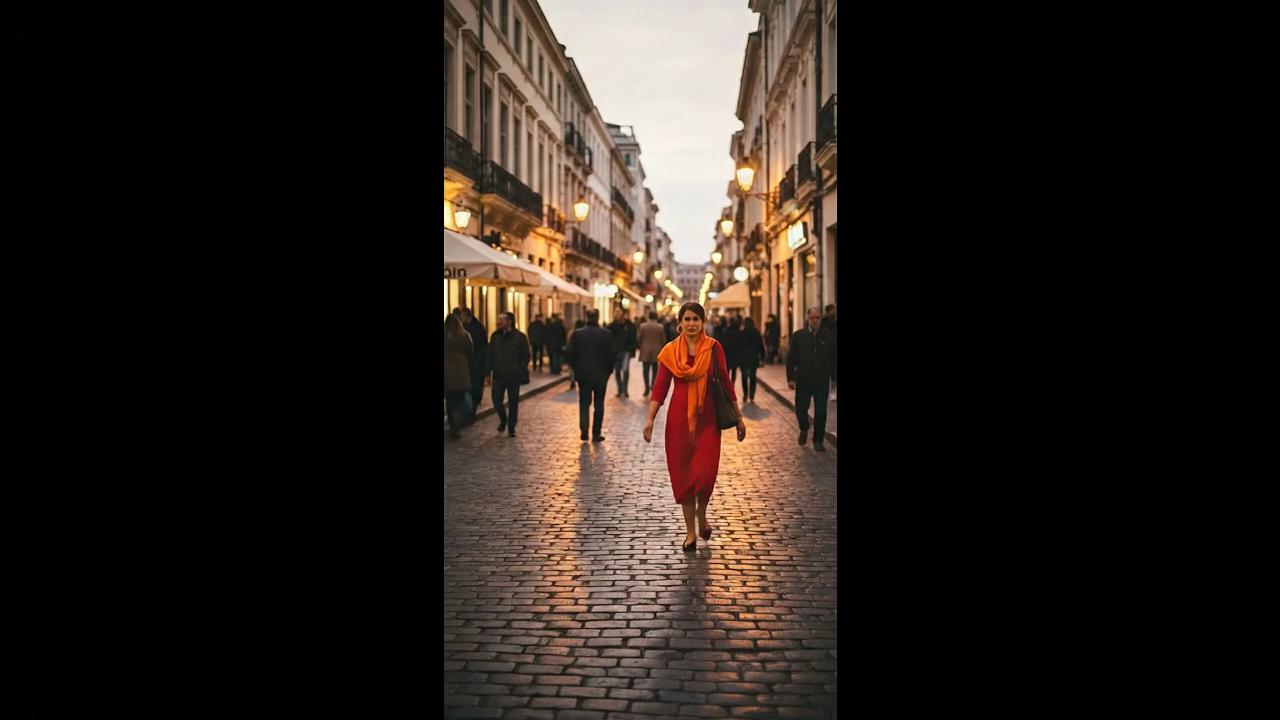
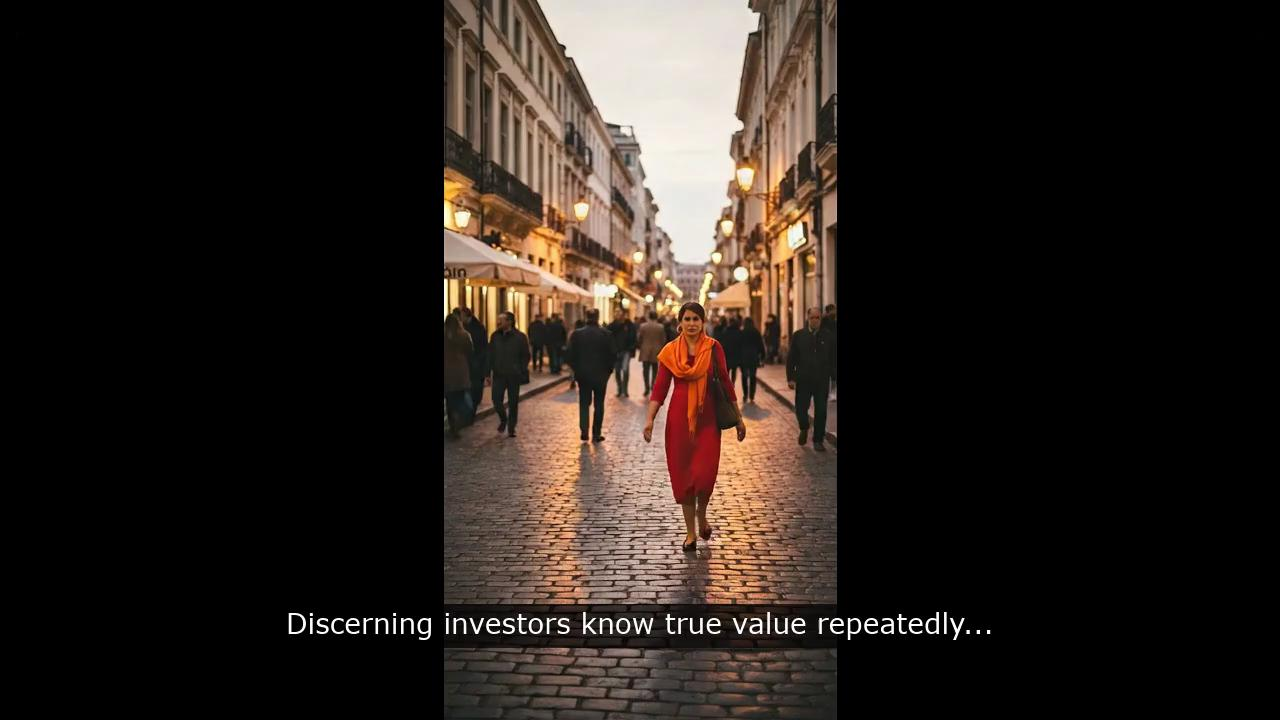
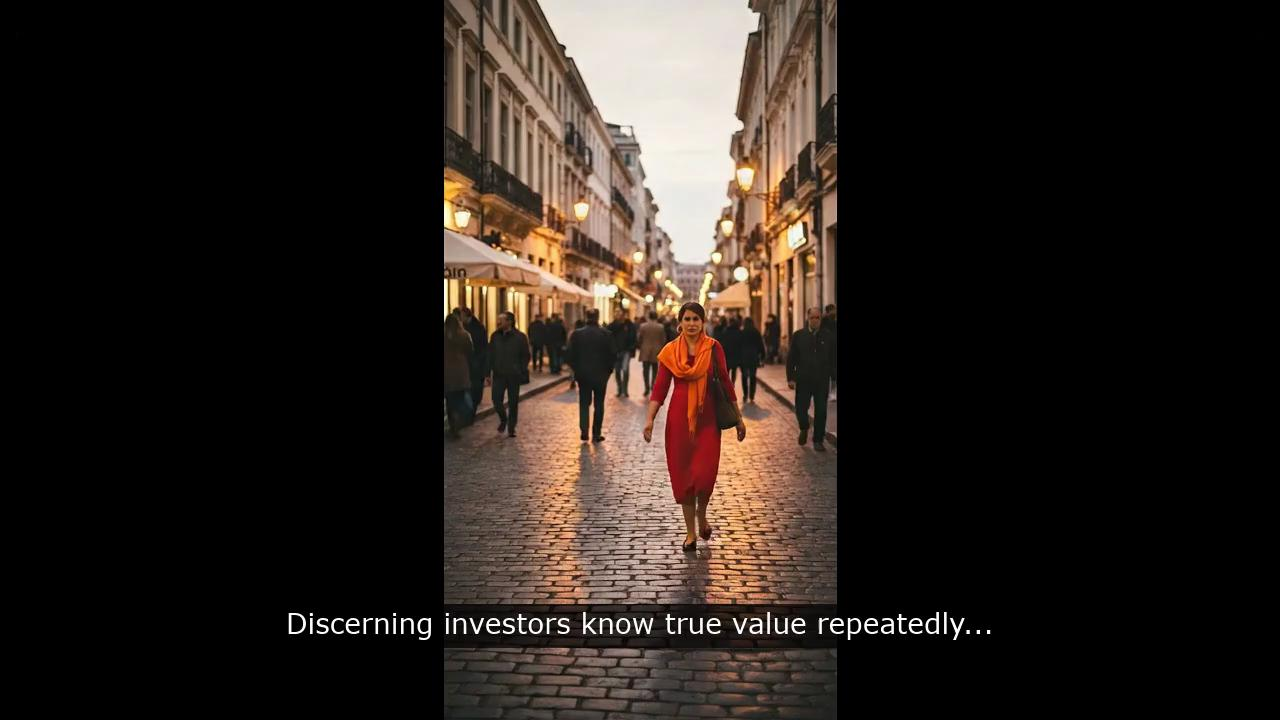
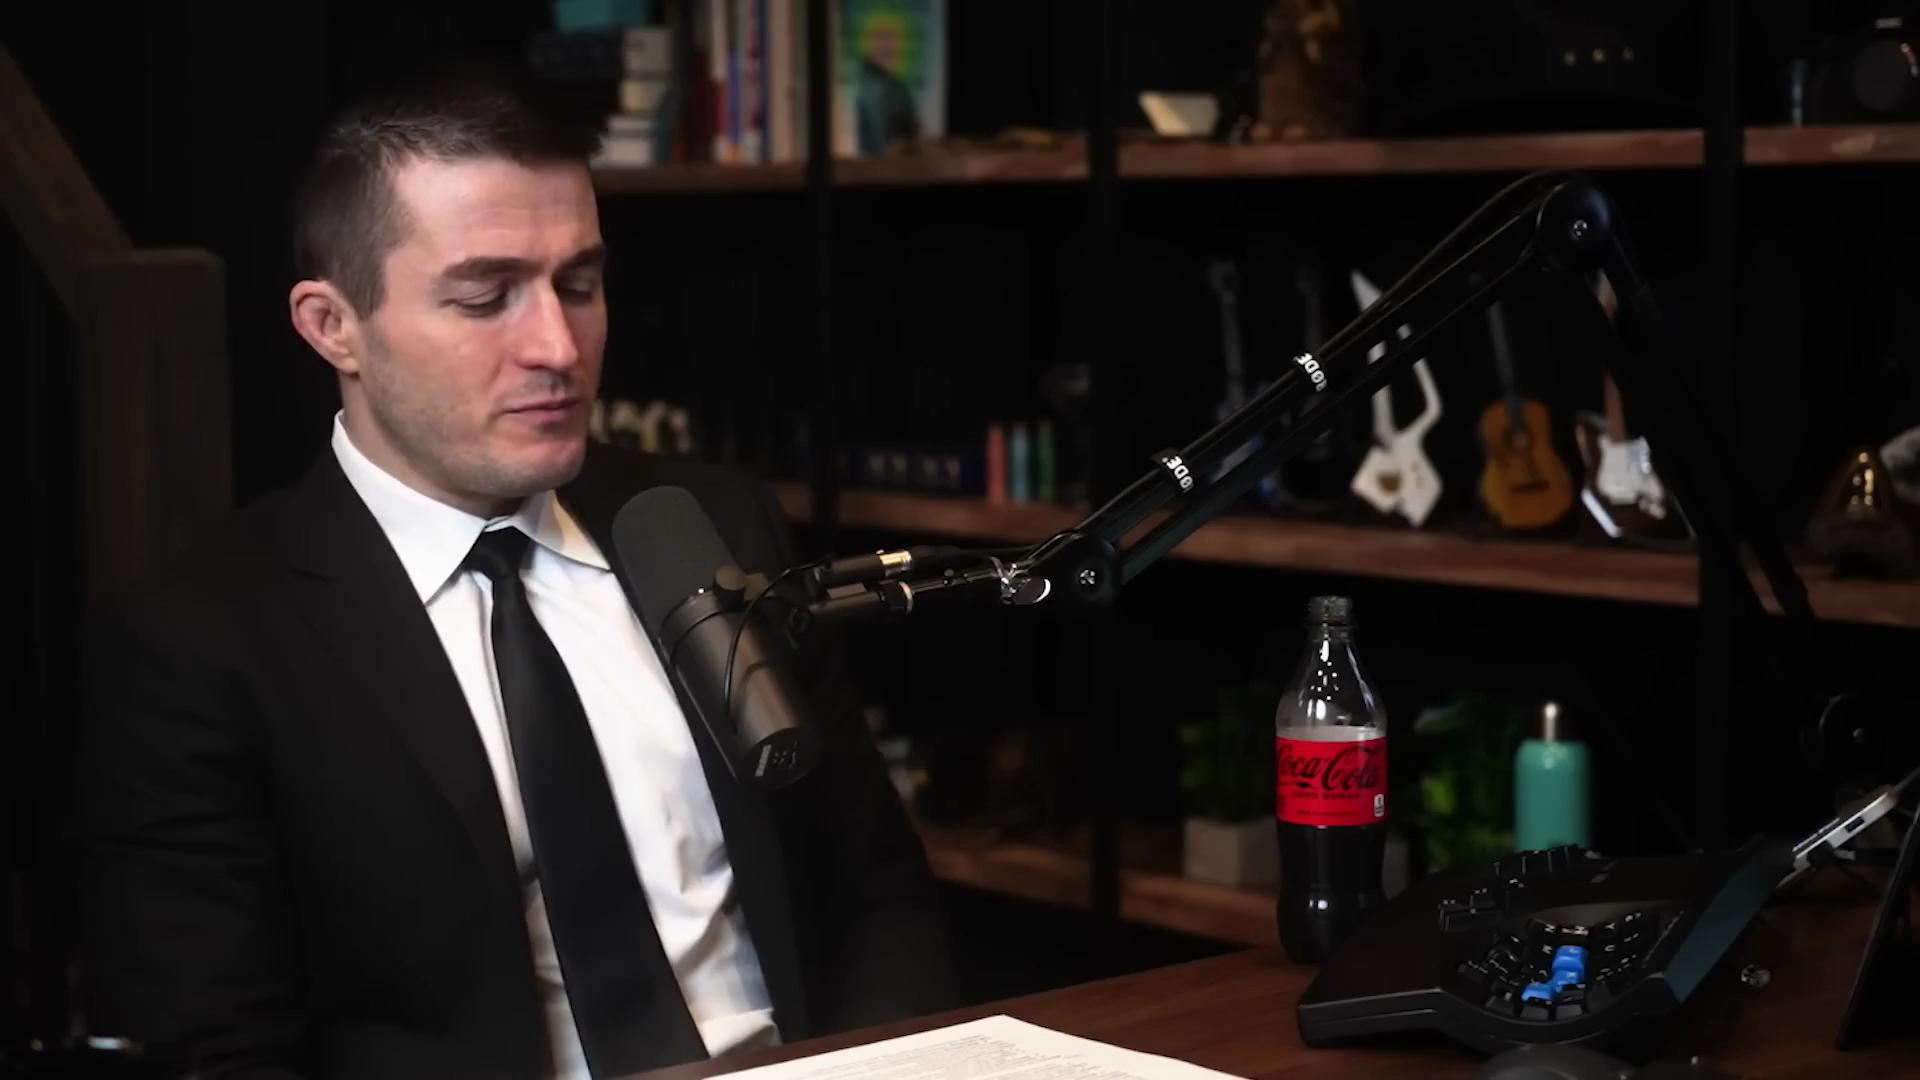
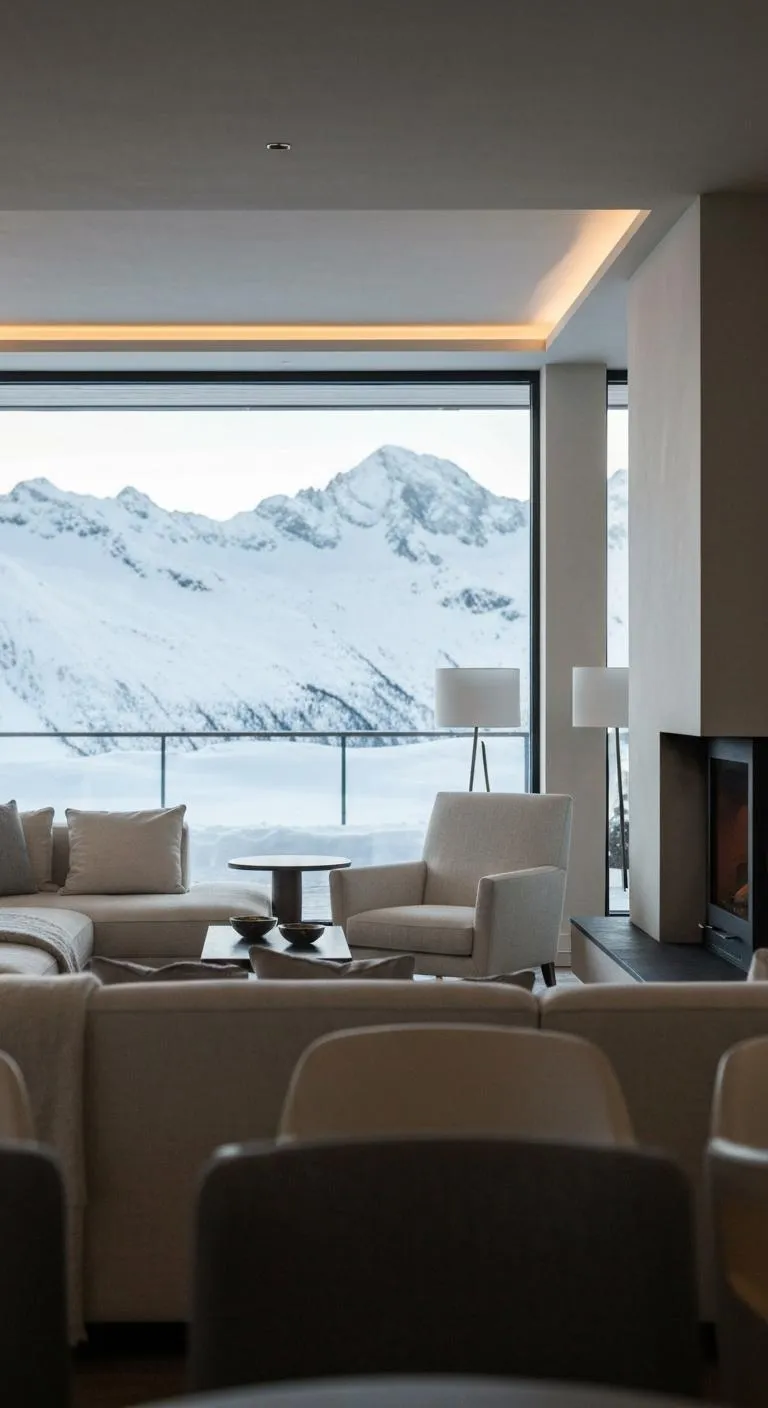
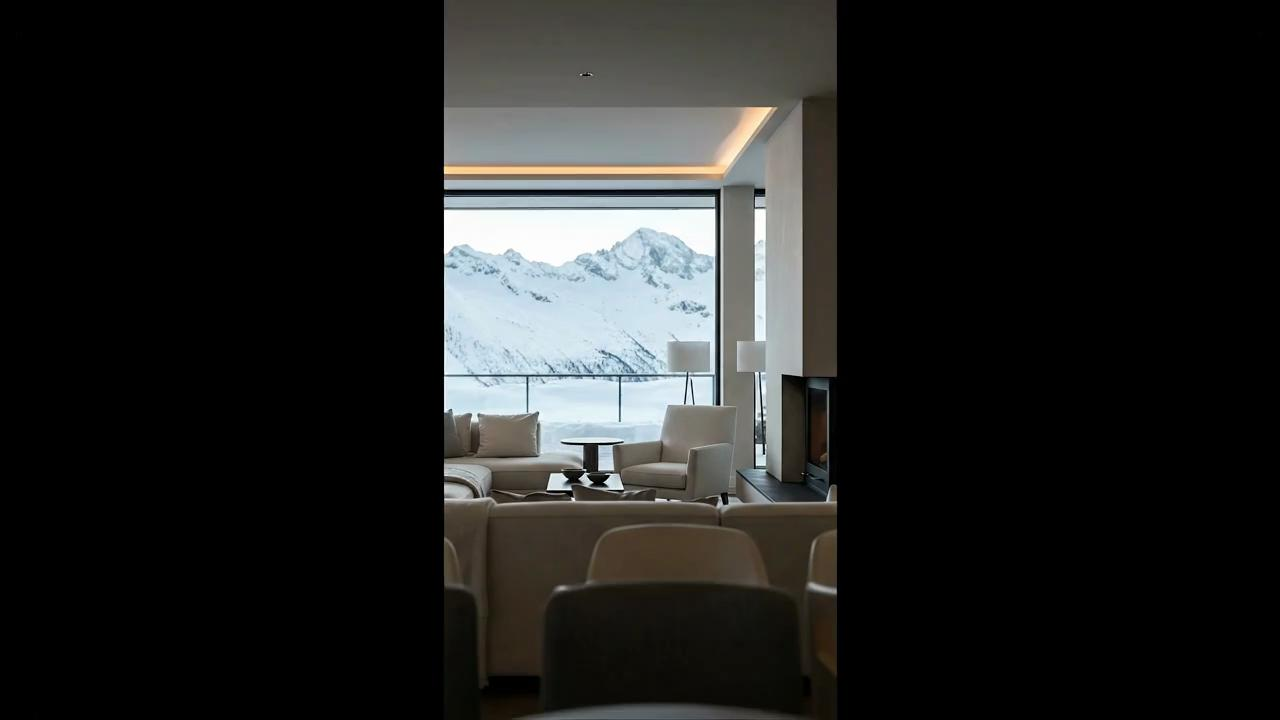
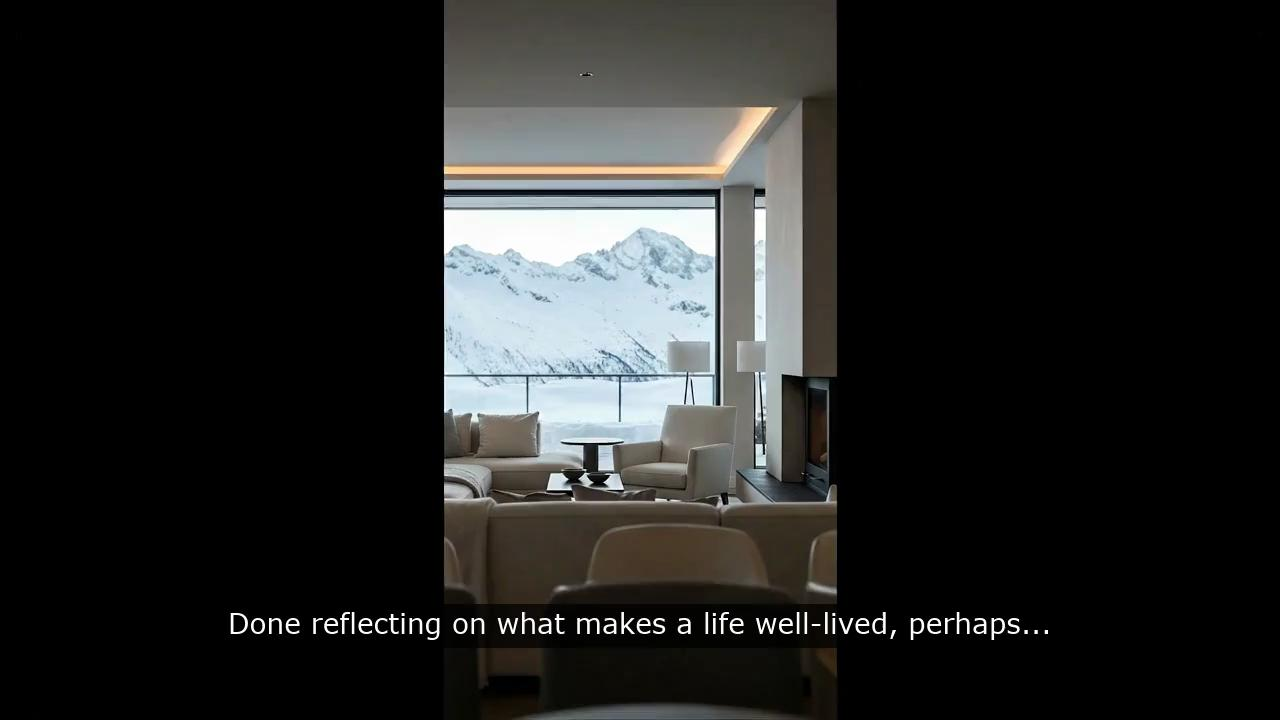
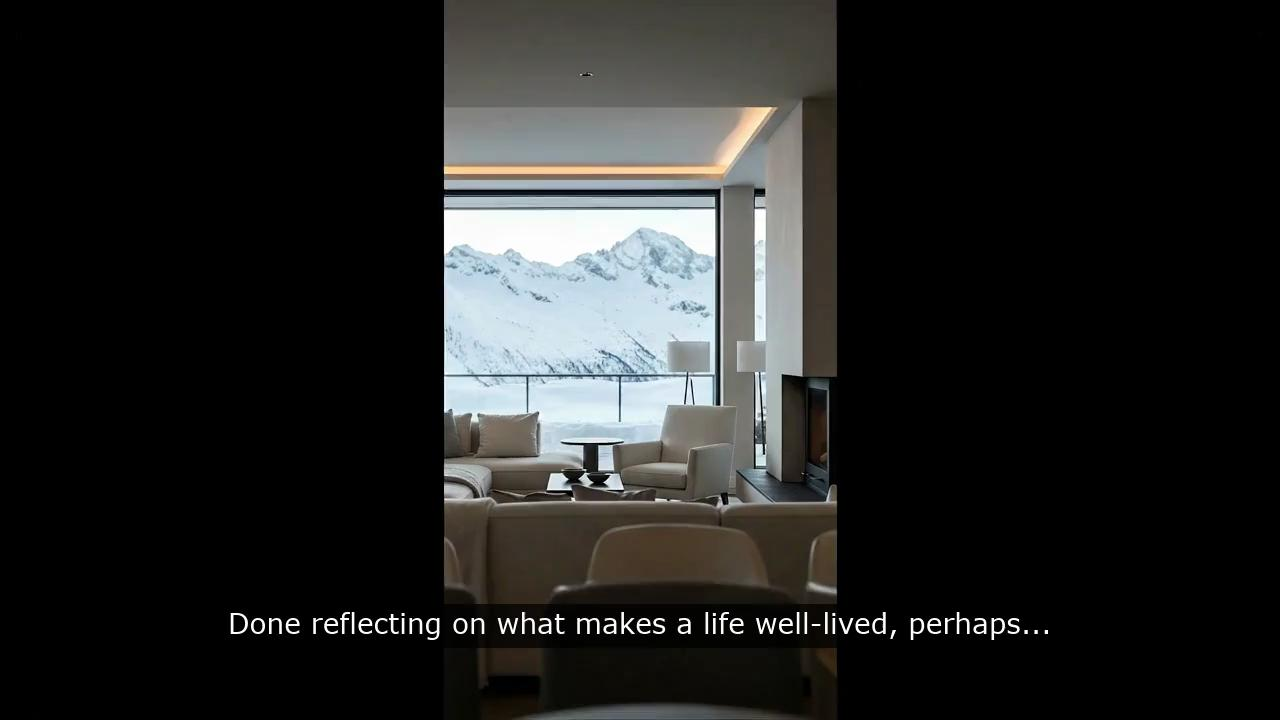

In [ ]:
ads.select(
    ads.target_audience,
    ads.ad_script,
    ads.captioned_ad
).collect()

## Bonus: Post-Processing with Video UDFs

Pixeltable has built-in video UDFs for common post-processing tasks. Here are a few applied to the generated ads.

### Crop: Reframe for a Different Aspect Ratio

`video.crop()` extracts a rectangular region. Here we crop the 9:16 portrait ads to a 1:1 square for Instagram — no re-encoding pipeline needed, just a query.

In [ ]:
ads.select(
    ads.target_audience,
    square_ad=ads.captioned_ad.crop([0, 280, 720, 720])
).head()

### Showreel: Concatenate All Ads

`concat_videos()` merges multiple videos into one. Collect all the generated ads and stitch them into a single showreel.

In [ ]:
all_ads = ads.select(ads.captioned_ad).collect()['captioned_ad'].tolist()
showreel = concat_videos(all_ads)
showreel

## Pipeline Overview

In [ ]:
ads.describe()

<style type="text/css">
#T_a74f2_row0_col0 {
  white-space: pre-wrap;
  text-align: left;
  font-weight: bold;
}
</style>
<table id="T_a74f2">
  <thead>
  </thead>
  <tbody>
    <tr>
      <td id="T_a74f2_row0_col0" class="data row0 col0" >table 'video_ads/ads'</td>
    </tr>
  </tbody>
</table>

<style type="text/css">
#T_061ca th {
  text-align: left;
  border-bottom: 2px solid #666;
}
#T_061ca_row0_col0, #T_061ca_row0_col1, #T_061ca_row0_col2, #T_061ca_row0_col3, #T_061ca_row0_col4, #T_061ca_row1_col0, #T_061ca_row1_col1, #T_061ca_row1_col2, #T_061ca_row1_col3, #T_061ca_row1_col4, #T_061ca_row2_col0, #T_061ca_row2_col1, #T_061ca_row2_col2, #T_061ca_row2_col3, #T_061ca_row2_col4, #T_061ca_row3_col0, #T_061ca_row3_col1, #T_061ca_row3_col2, #T_061ca_row3_col3, #T_061ca_row3_col4, #T_061ca_row4_col0, #T_061ca_row4_col1, #T_061ca_row4_col2, #T_061ca_row4_col3, #T_061ca_row4_col4, #T_061ca_row5_col0, #T_061ca_row5_col1, #T_061ca_row5_col2, #T_061ca_row5_col3, #T_061ca_row5_col4, #T_061ca_row6_col0, #T_061ca_row6_col1, #T_061ca_row6_col2, #T_061ca_row6_col3, #T_061ca_row6_col4, #T_061ca_row7_col0, #T_061ca_row7_col1, #T_061ca_row7_col2, #T_061ca_row7_col3, #T_061ca_row7_col4, #T_061ca_row8_col0, #T_061ca_row8_col1, #T_061ca_row8_col2, #T_061ca_row8_col3, #T_061ca_row8_col4, #T_061ca_row9_col0, #T_061ca_row9_col1, #T_061ca_row9_col2, #T_061ca_row9_col3, #T_061ca_row9_col4, #T_061ca_row10_col0, #T_061ca_row10_col1, #T_061ca_row10_col2, #T_061ca_row10_col3, #T_061ca_row10_col4, #T_061ca_row11_col0, #T_061ca_row11_col1, #T_061ca_row11_col2, #T_061ca_row11_col3, #T_061ca_row11_col4, #T_061ca_row12_col0, #T_061ca_row12_col1, #T_061ca_row12_col2, #T_061ca_row12_col3, #T_061ca_row12_col4, #T_061ca_row13_col0, #T_061ca_row13_col1, #T_061ca_row13_col2, #T_061ca_row13_col3, #T_061ca_row13_col4, #T_061ca_row14_col0, #T_061ca_row14_col1, #T_061ca_row14_col2, #T_061ca_row14_col3, #T_061ca_row14_col4, #T_061ca_row15_col0, #T_061ca_row15_col1, #T_061ca_row15_col2, #T_061ca_row15_col3, #T_061ca_row15_col4, #T_061ca_row16_col0, #T_061ca_row16_col1, #T_061ca_row16_col2, #T_061ca_row16_col3, #T_061ca_row16_col4, #T_061ca_row17_col0, #T_061ca_row17_col1, #T_061ca_row17_col2, #T_061ca_row17_col3, #T_061ca_row17_col4 {
  white-space: pre-wrap;
  text-align: left;
}
</style>
<table id="T_061ca">
  <thead>
    <tr>
      <th id="T_061ca_level0_col0" class="col_heading level0 col0" >Column Name</th>
      <th id="T_061ca_level0_col1" class="col_heading level0 col1" >Type</th>
      <th id="T_061ca_level0_col2" class="col_heading level0 col2" >Source</th>
      <th id="T_061ca_level0_col3" class="col_heading level0 col3" >Computed With</th>
      <th id="T_061ca_level0_col4" class="col_heading level0 col4" >Comment</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td id="T_061ca_row0_col0" class="data row0 col0" >video</td>
      <td id="T_061ca_row0_col1" class="data row0 col1" >Video</td>
      <td id="T_061ca_row0_col2" class="data row0 col2" >ads</td>
      <td id="T_061ca_row0_col3" class="data row0 col3" ></td>
      <td id="T_061ca_row0_col4" class="data row0 col4" ></td>
    </tr>
    <tr>
      <td id="T_061ca_row1_col0" class="data row1 col0" >property_type</td>
      <td id="T_061ca_row1_col1" class="data row1 col1" >String</td>
      <td id="T_061ca_row1_col2" class="data row1 col2" >ads</td>
      <td id="T_061ca_row1_col3" class="data row1 col3" ></td>
      <td id="T_061ca_row1_col4" class="data row1 col4" ></td>
    </tr>
    <tr>
      <td id="T_061ca_row2_col0" class="data row2 col0" >target_audience</td>
      <td id="T_061ca_row2_col1" class="data row2 col1" >String</td>
      <td id="T_061ca_row2_col2" class="data row2 col2" >ads</td>
      <td id="T_061ca_row2_col3" class="data row2 col3" ></td>
      <td id="T_061ca_row2_col4" class="data row2 col4" ></td>
    </tr>
    <tr>
      <td id="T_061ca_row3_col0" class="data row3 col0" >audio</td>
      <td id="T_061ca_row3_col1" class="data row3 col1" >Audio</td>
      <td id="T_061ca_row3_col2" class="data row3 col2" >ads</td>
      <td id="T_061ca_row3_col3" class="data row3 col3" >video.extract_audio(format='wav')</td>
      <td id="T_061ca_row3_col4" class="data row3 col4" ></td>
    </tr>
    <tr>
      <td id="T_061ca_row4_col0" class="data row4 col0" >transcription</td>
      <td id="T_061ca_row4_col1" class="data row4 col1" >Json</td>
      <td id="T_061ca_row4_col2" class="data row4 col2" >ads</td>
      <td id="T_061ca_row4_col3" class="data row4 col3" >transcribe(audio, model='base')</td>
      <td id="T_061ca_row4_col4" class="data row4 col4" ></td>
    </tr>
    <tr>
      <td id="T_061ca_row5_col0" class="data row5 col0" >transcript</td>
      <td id="T_061ca_row5_col1" class="data row5 col1" >String</td>
      <td id="T_061ca_row5_col2" class="data row5 col2" >ads</td>
      <td id="T_061ca_row5_col3" class="data row5 col3" >transcription.text.astype(String)</td>
      <td id="T_061ca_row5_col4" class="data row5 col4" ></td>
    </tr>
    <tr>
      <td id="T_061ca_row6_col0" class="data row6 col0" >analysis_contents</td>
      <td id="T_061ca_row6_col1" class="data row6 col1" >Json</td>
      <td id="T_061ca_row6_col2" class="data row6 col2" >ads</td>
      <td id="T_061ca_row6_col3" class="data row6 col3" >video_analysis_prompt(video, property_type)</td>
      <td id="T_061ca_row6_col4" class="data row6 col4" ></td>
    </tr>
    <tr>
      <td id="T_061ca_row7_col0" class="data row7 col0" >video_analysis</td>
      <td id="T_061ca_row7_col1" class="data row7 col1" >Json</td>
      <td id="T_061ca_row7_col2" class="data row7 col2" >ads</td>
      <td id="T_061ca_row7_col3" class="data row7 col3" >generate_content(analysis_contents, model='gemini-2.5-flash')</td>
      <td id="T_061ca_row7_col4" class="data row7 col4" ></td>
    </tr>
    <tr>
      <td id="T_061ca_row8_col0" class="data row8 col0" >analysis_text</td>
      <td id="T_061ca_row8_col1" class="data row8 col1" >String</td>
      <td id="T_061ca_row8_col2" class="data row8 col2" >ads</td>
      <td id="T_061ca_row8_col3" class="data row8 col3" >video_analysis.candidates[0].content.parts[0].text.astype(String)</td>
      <td id="T_061ca_row8_col4" class="data row8 col4" ></td>
    </tr>
    <tr>
      <td id="T_061ca_row9_col0" class="data row9 col0" >script_prompt</td>
      <td id="T_061ca_row9_col1" class="data row9 col1" >String</td>
      <td id="T_061ca_row9_col2" class="data row9 col2" >ads</td>
      <td id="T_061ca_row9_col3" class="data row9 col3" >ad_script_prompt(transcript, analysis_text, property_type, target_audience)</td>
      <td id="T_061ca_row9_col4" class="data row9 col4" ></td>
    </tr>
    <tr>
      <td id="T_061ca_row10_col0" class="data row10 col0" >script_response</td>
      <td id="T_061ca_row10_col1" class="data row10 col1" >Json</td>
      <td id="T_061ca_row10_col2" class="data row10 col2" >ads</td>
      <td id="T_061ca_row10_col3" class="data row10 col3" >generate_content(script_prompt, model='gemini-2.5-flash')</td>
      <td id="T_061ca_row10_col4" class="data row10 col4" ></td>
    </tr>
    <tr>
      <td id="T_061ca_row11_col0" class="data row11 col0" >ad_script</td>
      <td id="T_061ca_row11_col1" class="data row11 col1" >String</td>
      <td id="T_061ca_row11_col2" class="data row11 col2" >ads</td>
      <td id="T_061ca_row11_col3" class="data row11 col3" >script_response.candidates[0].content.parts[0].text.astype(String)</td>
      <td id="T_061ca_row11_col4" class="data row11 col4" ></td>
    </tr>
    <tr>
      <td id="T_061ca_row12_col0" class="data row12 col0" >image_prompt</td>
      <td id="T_061ca_row12_col1" class="data row12 col1" >String</td>
      <td id="T_061ca_row12_col2" class="data row12 col2" >ads</td>
      <td id="T_061ca_row12_col3" class="data row12 col3" >image_prompt(ad_script, property_type)</td>
      <td id="T_061ca_row12_col4" class="data row12 col4" ></td>
    </tr>
    <tr>
      <td id="T_061ca_row13_col0" class="data row13 col0" >hero_image</td>
      <td id="T_061ca_row13_col1" class="data row13 col1" >Image</td>
      <td id="T_061ca_row13_col2" class="data row13 col2" >ads</td>
      <td id="T_061ca_row13_col3" class="data row13 col3" >generate_images(image_prompt, model='imagen-4.0-fast-generate-001', config={'aspect_ratio': '9:16'})</td>
      <td id="T_061ca_row13_col4" class="data row13 col4" ></td>
    </tr>
    <tr>
      <td id="T_061ca_row14_col0" class="data row14 col0" >ad_video</td>
      <td id="T_061ca_row14_col1" class="data row14 col1" >Required[Video]</td>
      <td id="T_061ca_row14_col2" class="data row14 col2" >ads</td>
      <td id="T_061ca_row14_col3" class="data row14 col3" >generate_videos(prompt='Subtle cinematic camera movement, professional real estate footage, warm lighting, smooth motion. No text, no narration, no speech.', image=hero_image, model='veo-3.0-generate-001')</td>
      <td id="T_061ca_row14_col4" class="data row14 col4" ></td>
    </tr>
    <tr>
      <td id="T_061ca_row15_col0" class="data row15 col0" >caption</td>
      <td id="T_061ca_row15_col1" class="data row15 col1" >String</td>
      <td id="T_061ca_row15_col2" class="data row15 col2" >ads</td>
      <td id="T_061ca_row15_col3" class="data row15 col3" >clean_caption(ad_script)</td>
      <td id="T_061ca_row15_col4" class="data row15 col4" ></td>
    </tr>
    <tr>
      <td id="T_061ca_row16_col0" class="data row16 col0" >captioned_ad</td>
      <td id="T_061ca_row16_col1" class="data row16 col1" >Video</td>
      <td id="T_061ca_row16_col2" class="data row16 col2" >ads</td>
      <td id="T_061ca_row16_col3" class="data row16 col3" >ad_video.overlay_text(caption,
    font_size=28,
    color='white',
    box=True,
    box_color='black',
    box_opacity=0.7,
    box_border=[8, 16],
    horizontal_align='center',
    vertical_align='bottom',
    vertical_margin=80)</td>
      <td id="T_061ca_row16_col4" class="data row16 col4" ></td>
    </tr>
    <tr>
      <td id="T_061ca_row17_col0" class="data row17 col0" >final_video</td>
      <td id="T_061ca_row17_col1" class="data row17 col1" >Video</td>
      <td id="T_061ca_row17_col2" class="data row17 col2" >ads</td>
      <td id="T_061ca_row17_col3" class="data row17 col3" >captioned_ad</td>
      <td id="T_061ca_row17_col4" class="data row17 col4" ></td>
    </tr>
  </tbody>
</table>


## Customize This Pipeline

Pixeltable is the infrastructure. **You** decide what goes in the pipeline. Swap one step and everything downstream recomputes.

### Swap Any Model

```python
from pixeltable.functions import openai

ads.add_computed_column(
    script_response=openai.chat_completions(
        messages=[{'role': 'user', 'content': ads.script_prompt}],
        model='gpt-4o'
    )
)
```

```python
from pixeltable.functions import fal

ads.add_computed_column(
    ad_video=fal.run('fal-ai/luma-dream-machine/image-to-video', ...)
)
```

### Use Real Footage Instead of AI Visuals

```python
from pixeltable.functions.video import extract_frame

ads.add_computed_column(hero_image=extract_frame(ads.video, 5.0))
```

### Override Veo 3's Voiceover with Exact TTS

By default, Veo 3 generates the voiceover from the prompt. If you need word-for-word narration or a specific voice, use a dedicated TTS model and overlay it:

```python
from pixeltable.functions import huggingface
from pixeltable.functions.video import with_audio

ads.add_computed_column(
    narration=huggingface.text_to_speech(ads.ad_script, model_id='microsoft/speecht5_tts')
)
ads.add_computed_column(ad_with_narration=with_audio(ads.ad_video, ads.narration))
```

### Adapt for Any Industry

```python
ads.insert([{'video': car_review_url, 'property_type': 'SUV', 'target_audience': 'families'}])
ads.insert([{'video': hotel_tour_url, 'property_type': 'resort', 'target_audience': 'honeymooners'}])
```

### Tune Scene Detection

Adjust sensitivity to control which clip gets analyzed:

```python
ads.add_computed_column(
    scenes=ads.video.scene_detect_content(threshold=15.0, min_scene_len=30)
)
```

Or use a different detector — `scene_detect_adaptive()`, `scene_detect_hash()`, or `scene_detect_threshold()` for fade detection.

### Related Notebooks

- [Scene Detection](video-scene-detection.ipynb) — all detection algorithms with examples
- [Text Overlay & Crop](video-add-text-overlay.ipynb) — overlay_text, crop, bbox formats
- [Extract Frames](video-extract-frames.ipynb) — frame_iterator, extract_frame, make_video
- [Generate Videos with AI](video-generate-ai.ipynb) — Veo, Luma, Kling
- [Video Thumbnails](video-generate-thumbnails.ipynb)
- [Working with Gemini](../providers/working-with-gemini.ipynb)
- [Working with Tigris](../providers/working-with-tigris.ipynb)